# Data Collect

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/credit_default_prediction.xls")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [ ]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

# Data Quality & Cleaning

*   Renombrar Columnas
*   Cambiar tipo de dato
*   Eliminar valores constantes
*   Eliminar filas duplicadas
*   Eliminar con mayor cantidad de columnas nulas

## 2. Cambiar tipo de dato

In [ ]:
columnas_castear = {
    'SEX': 'category',
    'EDUCATION': 'category',
    'MARRIAGE': 'category',
    'PAY_0': 'category',
    'PAY_2': 'category',
    'PAY_3': 'category',
    'PAY_4': 'category',
    'PAY_5': 'category',
    'PAY_6': 'category',
    'default payment next month': 'category'
}
df =df.astype(columnas_castear)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   ID                          30000 non-null  int64   
 1   LIMIT_BAL                   30000 non-null  int64   
 2   SEX                         30000 non-null  category
 3   EDUCATION                   30000 non-null  category
 4   MARRIAGE                    30000 non-null  category
 5   AGE                         30000 non-null  int64   
 6   PAY_0                       30000 non-null  category
 7   PAY_2                       30000 non-null  category
 8   PAY_3                       30000 non-null  category
 9   PAY_4                       30000 non-null  category
 10  PAY_5                       30000 non-null  category
 11  PAY_6                       30000 non-null  category
 12  BILL_AMT1                   30000 non-null  int64   
 13  BILL_AMT2       

## 3. Eliminar valores constantes (Un único valor, en este caso no lo hay)

In [ ]:
df.nunique().sort_values(ascending=True)

,0
SEX,2
default payment next month,2
MARRIAGE,4
EDUCATION,7
PAY_5,10
PAY_6,10
PAY_2,11
PAY_4,11
PAY_3,11
PAY_0,11


In [ ]:
df.drop(columns = 'ID', inplace=True)

## 4. Eliminar filas duplicadas

In [ ]:
df[df.duplicated()]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1980,150000,2,1,1,38,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
4585,150000,2,1,1,31,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
6022,210000,2,1,2,39,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
6466,210000,2,2,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7319,500000,1,1,1,43,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
8320,360000,1,2,1,41,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
10250,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
13106,360000,2,1,1,49,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
14294,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
15458,160000,1,2,2,28,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(30000, 24)

In [ ]:
df.duplicated().sum()

np.int64(35)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(29965, 24)

## 5. Eliminar filas con mayor cantidad de columnas nulas

In [ ]:
print(df.shape)

(29965, 24)


In [ ]:
df.isnull().sum(axis=1).sort_values(ascending=False)

,0
29999,0
0,0
1,0
2,0
3,0
...,...
17,0
16,0
15,0
14,0


In [ ]:
df.dropna(thresh=17, inplace=True)
print(df.shape)

(29965, 24)


## a) Variables categóricas
1. Identificar las columnas con mayor cantidad de nulos
2. Imputar valores sobre celdas nulas:
   *  Valor Específico (Regla de negocio)
   *  Moda

In [ ]:
df_num=df.select_dtypes(include='number')
df_num

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,24,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,26,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,34,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,37,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,57,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,39,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,43,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,37,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,41,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [ ]:
df_num.shape

(29965, 14)

In [ ]:
df_cat = df.select_dtypes(exclude='number').copy()
df_cat

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default payment next month
0,2,2,1,2,2,-1,-1,-2,-2,1
1,2,2,2,-1,2,0,0,0,2,1
2,2,2,2,0,0,0,0,0,0,0
3,2,2,1,0,0,0,0,0,0,0
4,1,2,1,-1,0,-1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
29995,1,3,1,0,0,0,0,0,0,0
29996,1,3,2,-1,-1,-1,-1,0,0,0
29997,1,2,2,4,3,2,-1,0,0,1
29998,1,3,1,1,-1,0,0,0,-1,1


In [ ]:
df_cat.shape

(29965, 10)

### 1. Identificar las columnas con mayor cantidad de nulos

In [ ]:
df_cat.isnull().sum().sort_values(ascending=False)

,0
SEX,0
EDUCATION,0
MARRIAGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0
PAY_6,0
default payment next month,0


## b) Variables numéricas
1. Identificar las columnas con mayor cantidad de nulos
2. Imputar valores sobre celdas nulas:
   - Valor Específico
   - Medidas de tendencia central: Media, Mediana y Moda
3. Valores atípicos

### 1. Identificar las columnas con mayor cantidad de nulos

In [ ]:
df_num.isnull().sum().sort_values(ascending=False)

,0
LIMIT_BAL,0
AGE,0
BILL_AMT1,0
BILL_AMT2,0
BILL_AMT3,0
BILL_AMT4,0
BILL_AMT5,0
BILL_AMT6,0
PAY_AMT1,0
PAY_AMT2,0


## c) Outliers (Atípicos)

### Columnas Numéricas

In [ ]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  29965 non-null  int64
 1   AGE        29965 non-null  int64
 2   BILL_AMT1  29965 non-null  int64
 3   BILL_AMT2  29965 non-null  int64
 4   BILL_AMT3  29965 non-null  int64
 5   BILL_AMT4  29965 non-null  int64
 6   BILL_AMT5  29965 non-null  int64
 7   BILL_AMT6  29965 non-null  int64
 8   PAY_AMT1   29965 non-null  int64
 9   PAY_AMT2   29965 non-null  int64
 10  PAY_AMT3   29965 non-null  int64
 11  PAY_AMT4   29965 non-null  int64
 12  PAY_AMT5   29965 non-null  int64
 13  PAY_AMT6   29965 non-null  int64
dtypes: int64(14)
memory usage: 3.4 MB


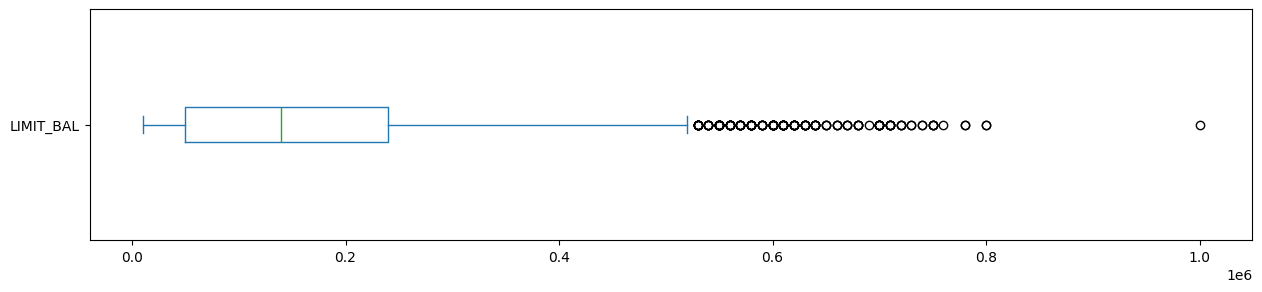

In [ ]:
df_num['LIMIT_BAL'].plot.box(figsize=(15,3), vert=False);

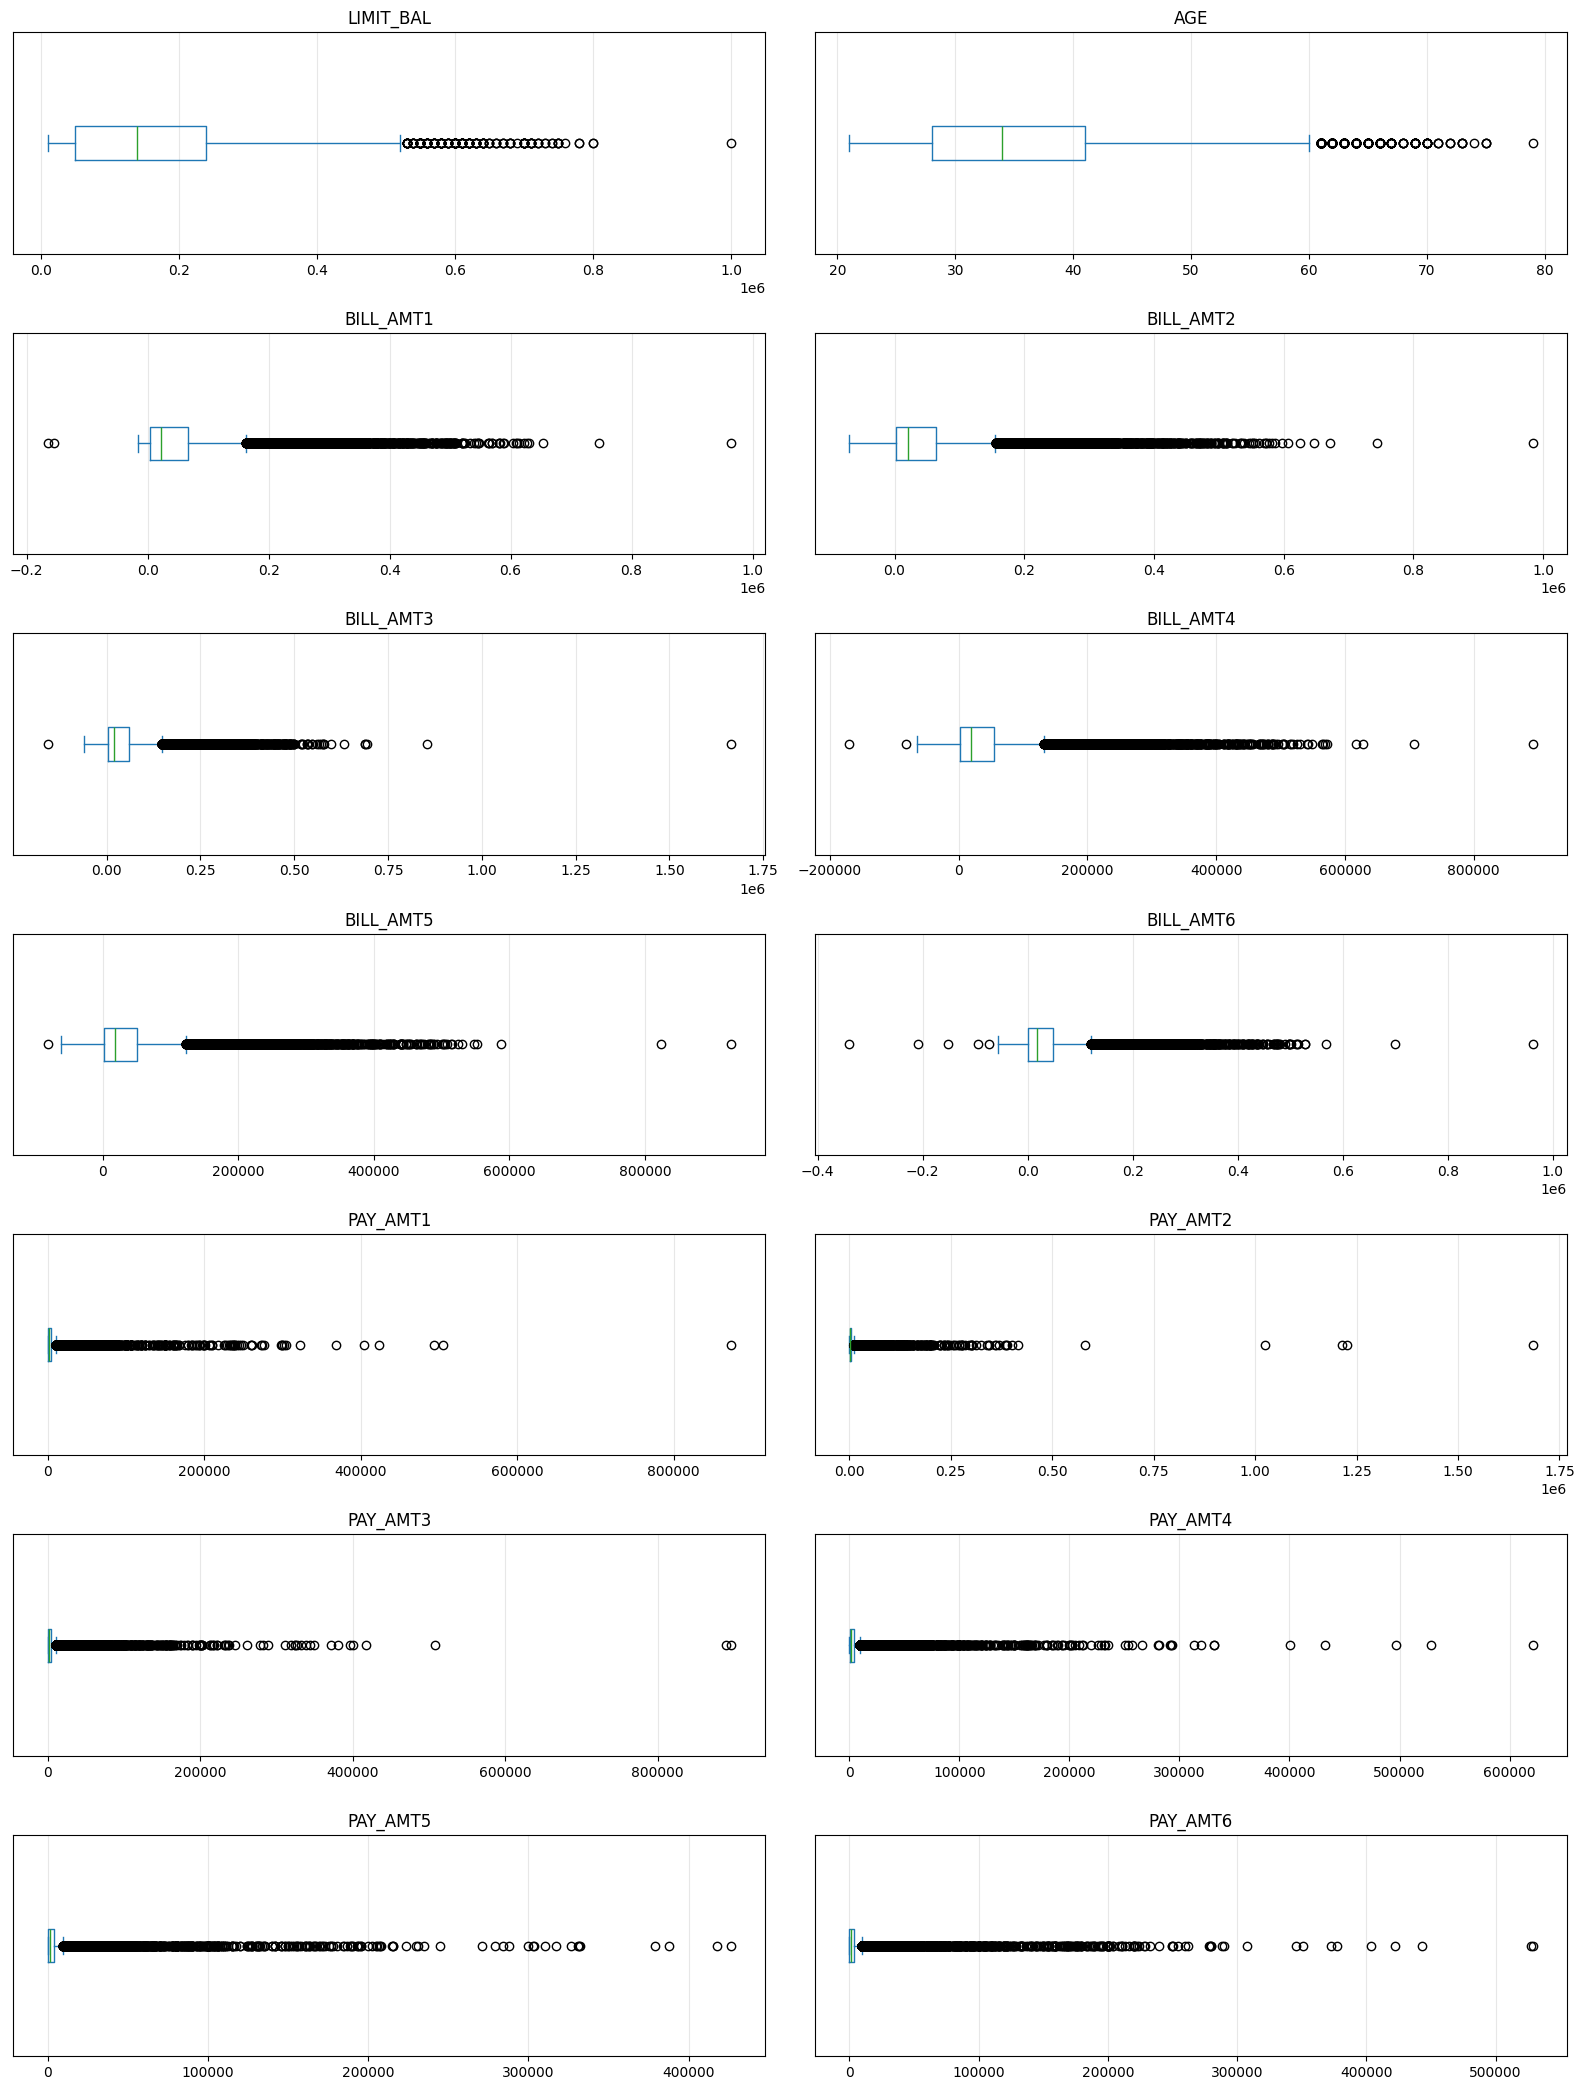

In [ ]:
import matplotlib.pyplot as plt
import math

n_columnas = 2
n_filas = math.ceil(len(df_num.columns) / n_columnas)

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(16, 3 * n_filas),
    squeeze=False
)

axes = axes.flatten()

for ax, columna in zip(axes, df_num.columns):
    df_num[columna].plot.box(ax=ax, vert=False)
    ax.set_title(columna)
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.3)

for ax in axes[len(df_num.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
resumen = df_num.describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

resumen["cantidad_ceros"] = df_num.eq(0).sum()
resumen["cantidad_negativos"] = df_num.lt(0).sum()

display(resumen.round(2))

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,cantidad_ceros,cantidad_negativos
LIMIT_BAL,29965.0,167442.01,129760.14,10000.0,10000.00,50000.0,140000.0,240000.0,430000.0,500000.00,1000000.0,0,0
AGE,29965.0,35.49,9.22,21.0,22.00,28.0,34.0,41.0,53.0,60.00,79.0,0,0
BILL_AMT1,29965.0,51283.01,73658.13,-165580.0,-81.00,3595.0,22438.0,67260.0,201303.8,350134.48,964511.0,1978,590
BILL_AMT2,29965.0,49236.37,71195.57,-69777.0,-200.00,3010.0,21295.0,64109.0,194889.6,337505.08,983931.0,2476,669
BILL_AMT3,29965.0,47067.92,69371.35,-157264.0,-200.00,2711.0,20135.0,60201.0,187901.0,325254.04,1664089.0,2840,655
BILL_AMT4,29965.0,43313.33,64353.51,-170000.0,-212.72,2360.0,19081.0,54601.0,174469.8,305006.72,891586.0,3165,675
BILL_AMT5,29965.0,40358.33,60817.13,-81334.0,-232.36,1787.0,18130.0,50247.0,165805.6,285879.88,927171.0,3476,655
BILL_AMT6,29965.0,38917.01,59574.15,-339603.0,-332.08,1262.0,17124.0,49252.0,161932.0,279577.16,961664.0,3990,688
PAY_AMT1,29965.0,5670.10,16571.85,0.0,0.00,1000.0,2102.0,5008.0,18447.2,66843.48,873552.0,5218,0
PAY_AMT2,29965.0,5927.98,23053.46,0.0,0.00,850.0,2010.0,5000.0,19030.8,76651.72,1684259.0,5365,0


### Columnas Categoricas

* Estrategias categóricas
   * Imputar por un valor establecido
   * Imputar por la moda

In [ ]:
df_cat.info();

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   SEX                         29965 non-null  category
 1   EDUCATION                   29965 non-null  category
 2   MARRIAGE                    29965 non-null  category
 3   PAY_0                       29965 non-null  category
 4   PAY_2                       29965 non-null  category
 5   PAY_3                       29965 non-null  category
 6   PAY_4                       29965 non-null  category
 7   PAY_5                       29965 non-null  category
 8   PAY_6                       29965 non-null  category
 9   default payment next month  29965 non-null  category
dtypes: category(10)
memory usage: 529.8 KB


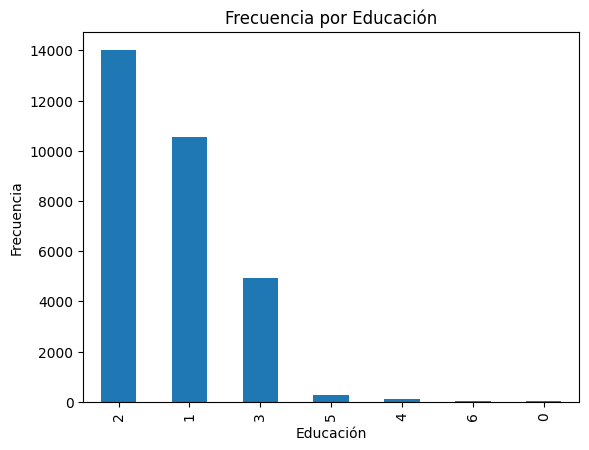

In [ ]:
ax = df_cat['EDUCATION'].value_counts().plot(kind='bar');
ax.set_ylabel("Frecuencia")
ax.set_xlabel("Educación")
ax.set_title("Frecuencia por Educación");

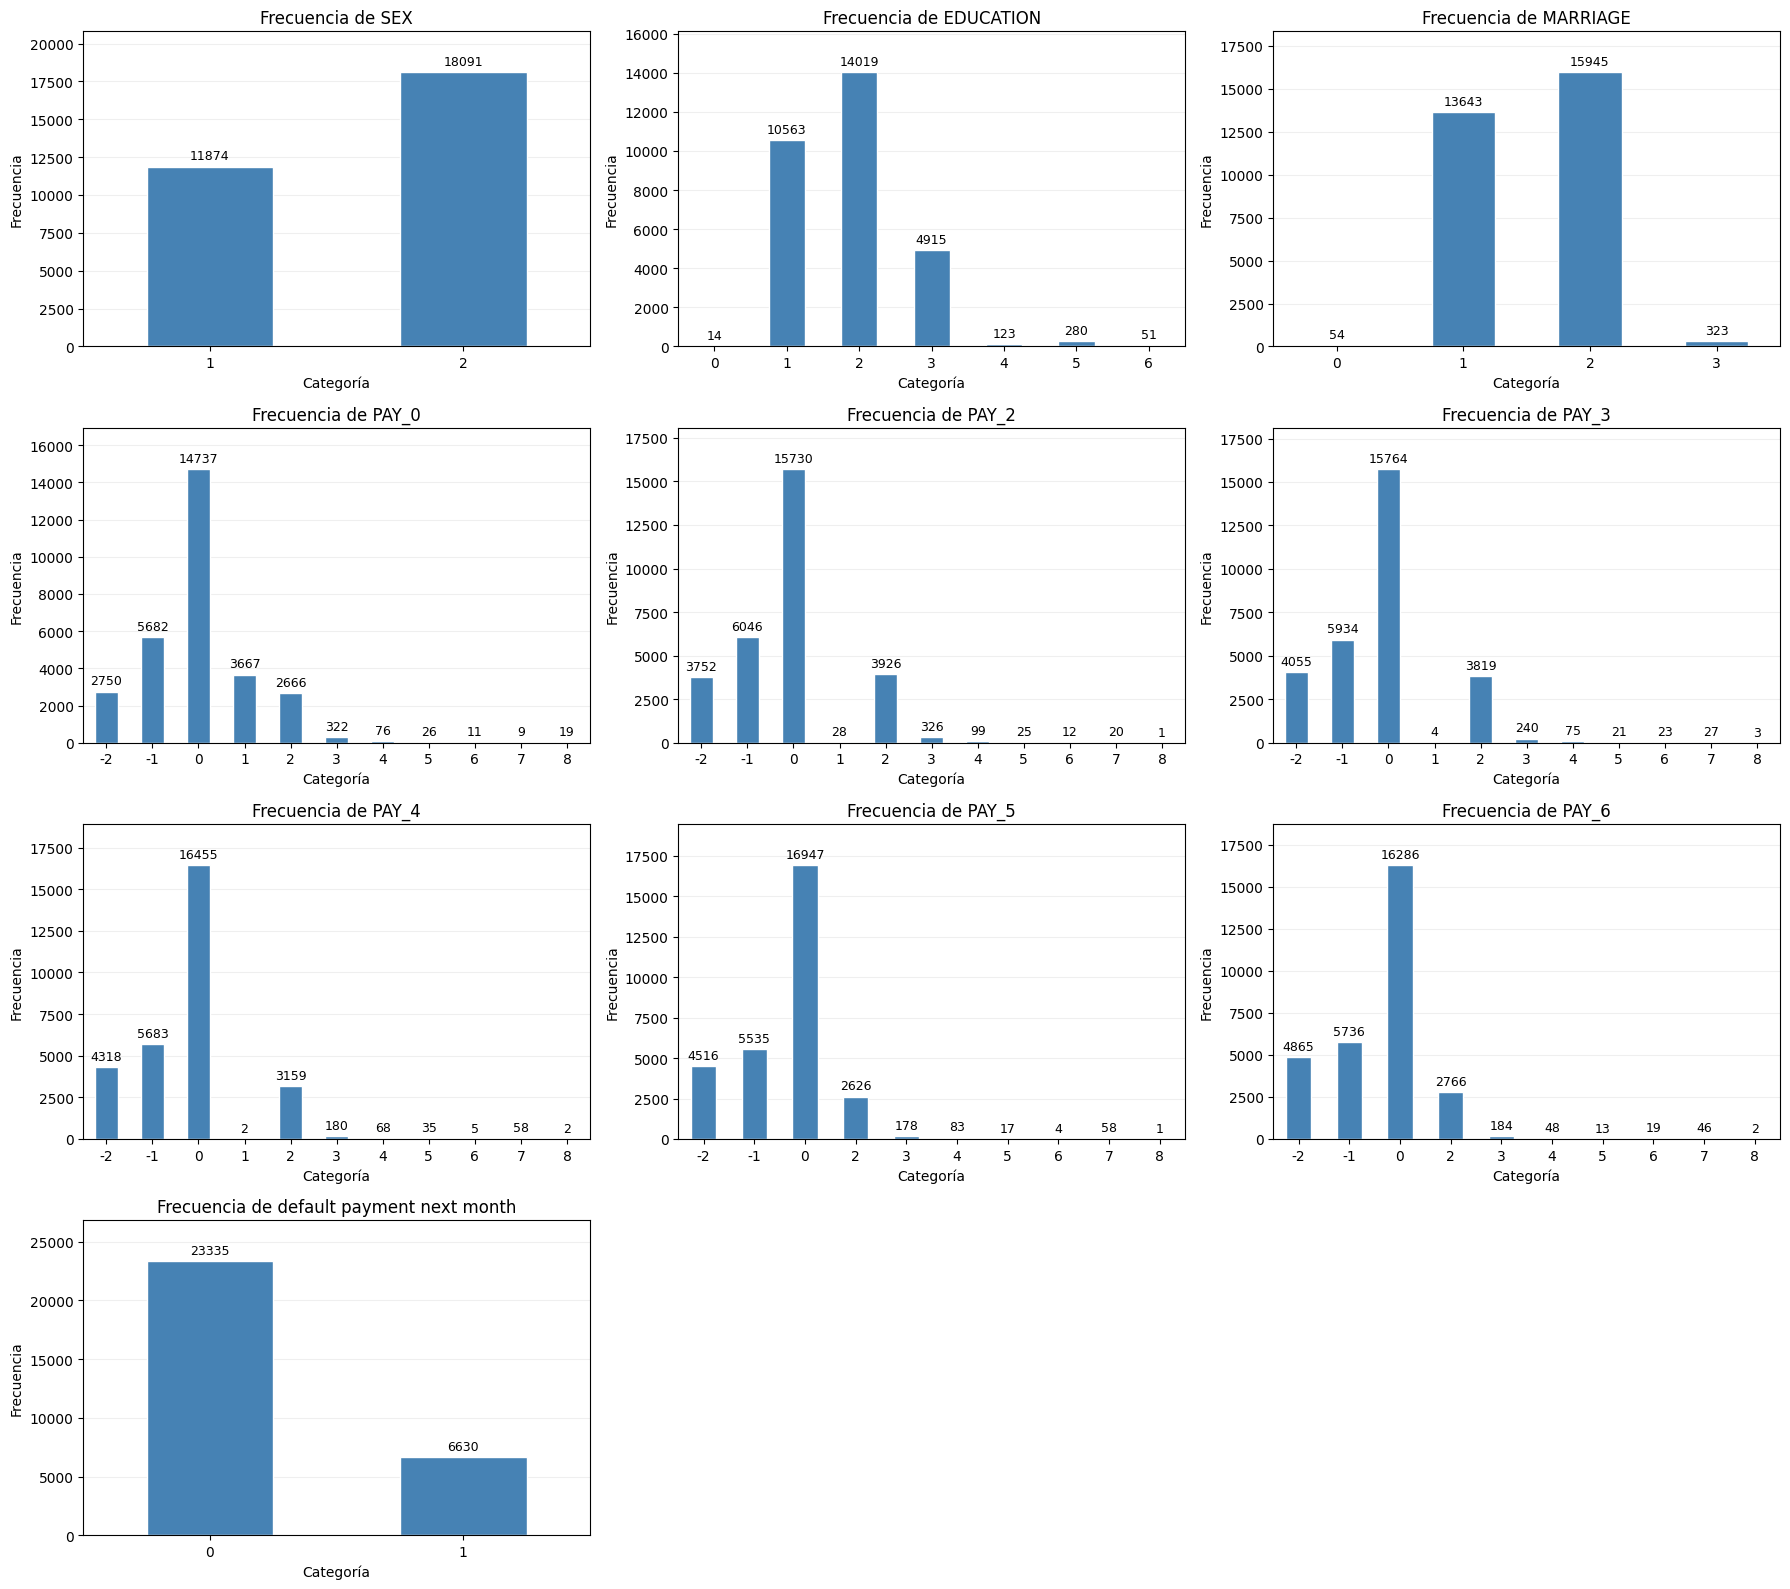

In [ ]:
n_columnas = 3
n_filas = math.ceil(len(df_cat.columns) / n_columnas)

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 4 * n_filas),
    squeeze=False
)

axes = axes.flatten()

for ax, columna in zip(axes, df_cat.columns):
    frecuencias = df_cat[columna].value_counts(
        sort=False,
        dropna=False
    ).sort_index()

    frecuencias.plot(
        kind="bar",
        ax=ax,
        color="steelblue",
        edgecolor="white"
    )

    ax.set_title(f"Frecuencia de {columna}")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=0)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=9)

    ax.margins(y=0.15)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

for ax in axes[len(df_cat.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

#### Colocamos las etiquetas correspondientes de cada variable de acuerdo a la info del dataset

In [ ]:
etiquetas = {
    "SEX": {
        1: "Masculino",
        2: "Femenino"
    },
    "EDUCATION": {
        0: "No especificado (0)",
        1: "Posgrado",
        2: "Universidad",
        3: "Secundaria",
        4: "Otros",
        5: "No especificado (5)",
        6: "No especificado (6)"
    },
    "MARRIAGE": {
        0: "No especificado (0)",
        1: "Casado/a",
        2: "Soltero/a",
        3: "Otros"
    },
    "default payment next month": {
        0: "Sin incumplimiento",
        1: "Con incumplimiento"
    }
}

etiquetas_pagos = {
    -2: "No especificado (-2)",
    -1: "Pago a tiempo",
     0: "No especificado (0)",
     1: "Atraso de 1 mes",
     2: "Atraso de 2 meses",
     3: "Atraso de 3 meses",
     4: "Atraso de 4 meses",
     5: "Atraso de 5 meses",
     6: "Atraso de 6 meses",
     7: "Atraso de 7 meses",
     8: "Atraso de 8 meses",
     9: "Atraso de 9 meses o más"
}

columnas_pagos = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

for columna in columnas_pagos:
    etiquetas[columna] = etiquetas_pagos.copy()

#### Mostramos el resultado y colocamos algunos datos que no estaban registrados como "No especificada"

In [ ]:
# Copia con nombres descriptivos
df_cat_etiquetado = df_cat.copy()

for columna, mapa in etiquetas.items():
    if columna in df_cat_etiquetado.columns:
        serie = df_cat_etiquetado[columna]

        sin_etiqueta = [
            valor
            for valor in serie.dropna().unique()
            if valor not in mapa
        ]

        if sin_etiqueta:
            raise ValueError(
                f"{columna}: códigos sin etiqueta: {sin_etiqueta}"
            )

        df_cat_etiquetado[columna] = (
            serie.astype(object)
                 .map(mapa)
                 .astype("category")
        )

display(df_cat_etiquetado.head())

for columna in df_cat_etiquetado.columns:
    print(f"\n--- {columna} ---")
    display(
        df_cat_etiquetado[columna]
        .value_counts(dropna=False)
        .rename("Frecuencia")
        .to_frame()
    )

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default payment next month
0,Femenino,Universidad,Casado/a,Atraso de 2 meses,Atraso de 2 meses,Pago a tiempo,Pago a tiempo,No especificado (-2),No especificado (-2),Con incumplimiento
1,Femenino,Universidad,Soltero/a,Pago a tiempo,Atraso de 2 meses,No especificado (0),No especificado (0),No especificado (0),Atraso de 2 meses,Con incumplimiento
2,Femenino,Universidad,Soltero/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento
3,Femenino,Universidad,Casado/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento
4,Masculino,Universidad,Casado/a,Pago a tiempo,No especificado (0),Pago a tiempo,No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento



--- SEX ---


,Frecuencia
SEX,
Femenino,18091
Masculino,11874



--- EDUCATION ---


,Frecuencia
EDUCATION,
Universidad,14019
Posgrado,10563
Secundaria,4915
No especificado (5),280
Otros,123
No especificado (6),51
No especificado (0),14


...

,Frecuencia
PAY_5,
No especificado (0),16947
Pago a tiempo,5535
No especificado (-2),4516
Atraso de 2 meses,2626
Atraso de 3 meses,178
Atraso de 4 meses,83
Atraso de 7 meses,58
Atraso de 5 meses,17
Atraso de 6 meses,4



--- PAY_6 ---


,Frecuencia
PAY_6,
No especificado (0),16286
Pago a tiempo,5736
No especificado (-2),4865
Atraso de 2 meses,2766
Atraso de 3 meses,184
Atraso de 4 meses,48
Atraso de 7 meses,46
Atraso de 6 meses,19
Atraso de 5 meses,13



--- default payment next month ---


,Frecuencia
default payment next month,
Sin incumplimiento,23335
Con incumplimiento,6630


# EDA - Análisis Exploratorio

## Análisis Univariado

### Var Categóricas

In [ ]:
df_cat_etiquetado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   SEX                         29965 non-null  category
 1   EDUCATION                   29965 non-null  category
 2   MARRIAGE                    29965 non-null  category
 3   PAY_0                       29965 non-null  category
 4   PAY_2                       29965 non-null  category
 5   PAY_3                       29965 non-null  category
 6   PAY_4                       29965 non-null  category
 7   PAY_5                       29965 non-null  category
 8   PAY_6                       29965 non-null  category
 9   default payment next month  29965 non-null  category
dtypes: category(10)
memory usage: 529.8 KB


#### Conteos

In [ ]:
df_cat_etiquetado['default payment next month'].value_counts()

,count
default payment next month,
Sin incumplimiento,23335
Con incumplimiento,6630


In [ ]:
df_cat['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,15945
1,13643
3,323
0,54


In [ ]:
df_cat_etiquetado['MARRIAGE'].value_counts()

,count
MARRIAGE,
Soltero/a,15945
Casado/a,13643
Otros,323
No especificado (0),54


#### Proporciones

In [ ]:
df_cat_etiquetado['default payment next month'].value_counts(normalize=True)

,proportion
default payment next month,
Sin incumplimiento,0.778742
Con incumplimiento,0.221258


In [ ]:
df_cat_etiquetado['EDUCATION'].value_counts(normalize=True)

,proportion
EDUCATION,
Universidad,0.467846
Posgrado,0.352511
Secundaria,0.164025
No especificado (5),0.009344
Otros,0.004105
No especificado (6),0.001702
No especificado (0),0.000467


#### Moda

Los valores mas comunes para cada columna

* Use el dataframe
* Use el método ***.mode()***

In [ ]:
df_cat_etiquetado.mode()

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default payment next month
0,Femenino,Universidad,Soltero/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento


### Var Numéricas

In [ ]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  29965 non-null  int64
 1   AGE        29965 non-null  int64
 2   BILL_AMT1  29965 non-null  int64
 3   BILL_AMT2  29965 non-null  int64
 4   BILL_AMT3  29965 non-null  int64
 5   BILL_AMT4  29965 non-null  int64
 6   BILL_AMT5  29965 non-null  int64
 7   BILL_AMT6  29965 non-null  int64
 8   PAY_AMT1   29965 non-null  int64
 9   PAY_AMT2   29965 non-null  int64
 10  PAY_AMT3   29965 non-null  int64
 11  PAY_AMT4   29965 non-null  int64
 12  PAY_AMT5   29965 non-null  int64
 13  PAY_AMT6   29965 non-null  int64
dtypes: int64(14)
memory usage: 3.4 MB


#### Media o Promedio (T.Central)
El promedio del ingreso de los aplicantes
* Columna : 'ingreso_aplicante'
* Método : **mean()**

In [ ]:
df_num['AGE'].mean()

np.float64(35.487969297513764)

#### Estadísticos básicos (Dispersión)
Descripcion de las variables en estadísticos básicos **(conteo, media, mediana, std, cuartiles, rangos)**   
* Cree un dataframe : 'df_num_statistics'
* Asigne el resultado del método ***describe().T***

In [ ]:
df_num_statistic = df_num.describe().T
df_num_statistic

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
BILL_AMT1,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0
BILL_AMT2,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0
BILL_AMT3,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0
BILL_AMT4,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0
BILL_AMT5,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0
BILL_AMT6,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0
PAY_AMT1,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0
PAY_AMT2,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0


In [ ]:
df_num_statistic['rango'] = df_num_statistic.loc[:,'max'] - df_num_statistic.loc[:,'min']
df_num_statistic

,count,mean,std,min,25%,50%,75%,max,rango
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0,990000.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0,58.0
BILL_AMT1,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0,1130091.0
BILL_AMT2,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0,1053708.0
BILL_AMT3,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0,1821353.0
BILL_AMT4,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0,1061586.0
BILL_AMT5,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0,1008505.0
BILL_AMT6,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0,1301267.0
PAY_AMT1,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0,873552.0
PAY_AMT2,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0,1684259.0


#### BoxPlot (Dispersión)

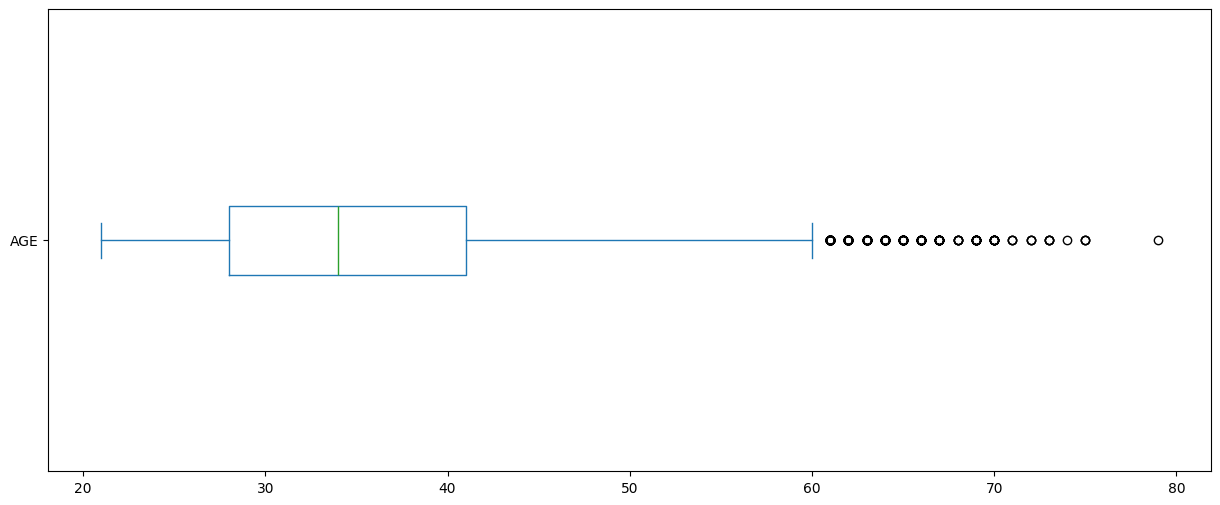

In [ ]:
df_num['AGE'].plot.box(figsize = (15,6), vert=False);

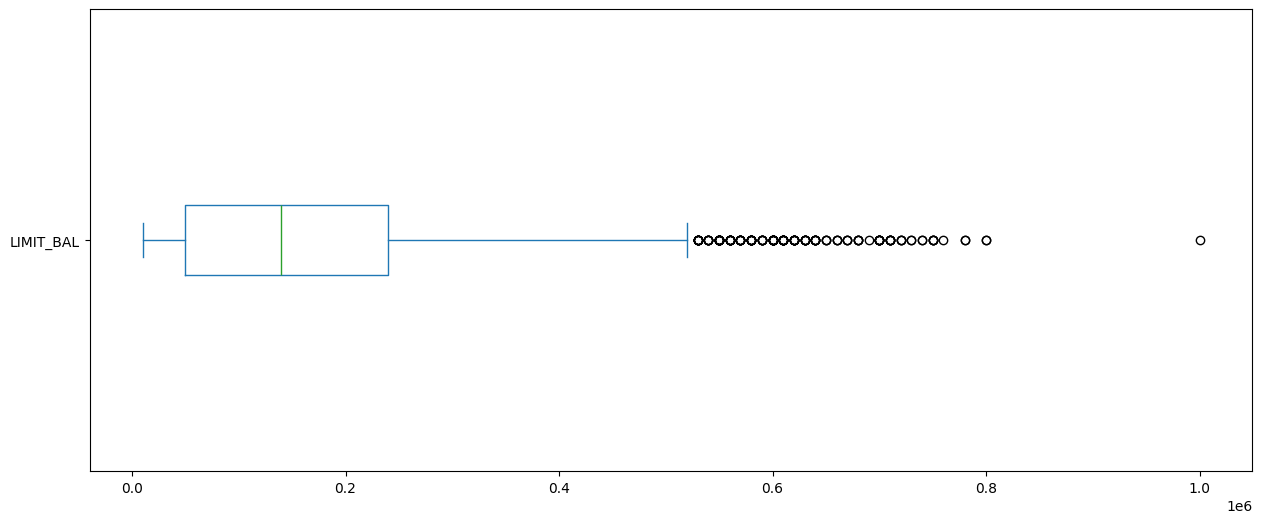

In [ ]:
df_num['LIMIT_BAL'].plot.box(figsize = (15,6), vert=False);

#### Histogramas (Formas)

Histograma para variable "Monto del crédito otorgado o Limit Bal" de df_num, use "plot.hist"

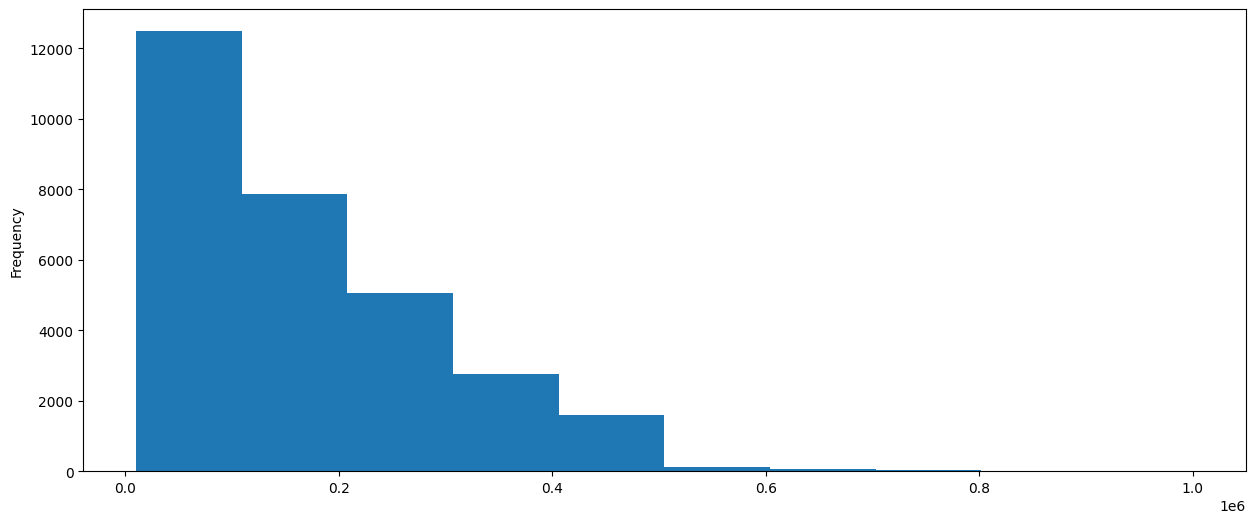

In [ ]:
df_num['LIMIT_BAL'].plot.hist(figsize = (15,6));

### Análisis Bivariado (UNION DE DATAFRANES NUM AND CATEGORY

Unimos en un dataframe las categoricas y las numericas
* use concat con axis = 1
* guardelo en df_cat_num

In [ ]:
df_cat_num = pd.concat([df_cat_etiquetado,df_num], axis =1 ) # CONCATENER AMBOS DATAFRAMES
df_cat_num

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default payment next month,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,Femenino,Universidad,Casado/a,Atraso de 2 meses,Atraso de 2 meses,Pago a tiempo,Pago a tiempo,No especificado (-2),No especificado (-2),Con incumplimiento,...,689,0,0,0,0,689,0,0,0,0
1,Femenino,Universidad,Soltero/a,Pago a tiempo,Atraso de 2 meses,No especificado (0),No especificado (0),No especificado (0),Atraso de 2 meses,Con incumplimiento,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,Femenino,Universidad,Soltero/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,Femenino,Universidad,Casado/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,Masculino,Universidad,Casado/a,Pago a tiempo,No especificado (0),Pago a tiempo,No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,Masculino,Secundaria,Casado/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),Sin incumplimiento,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,Masculino,Secundaria,Soltero/a,Pago a tiempo,Pago a tiempo,Pago a tiempo,Pago a tiempo,No especificado (0),No especificado (0),Sin incumplimiento,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,Masculino,Universidad,Soltero/a,Atraso de 4 meses,Atraso de 3 meses,Atraso de 2 meses,Pago a tiempo,No especificado (0),No especificado (0),Con incumplimiento,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,Masculino,Secundaria,Casado/a,Atraso de 1 mes,Pago a tiempo,No especificado (0),No especificado (0),No especificado (0),Pago a tiempo,Con incumplimiento,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


#### Numérico vs Numéricos

##### Scatter

Muestre la interacción entre las variables 'LIMIT BAL' y 'BILL_AMT1'   

Si los clientes con mayor límite presentan montos facturados más altos.

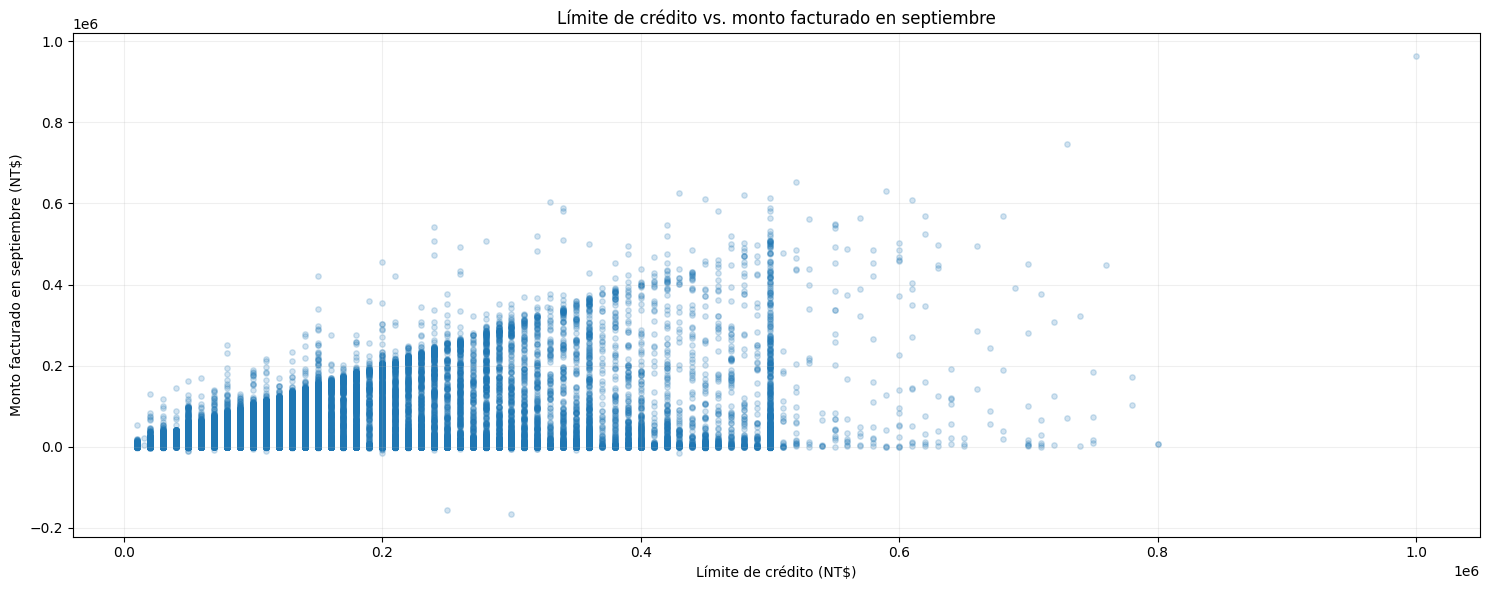

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(
    data=df_num,
    x="LIMIT_BAL",
    y="BILL_AMT1",
    alpha=0.2,
    s=15
)

ax.set_title("Límite de crédito vs. monto facturado en septiembre")
ax.set_xlabel("Límite de crédito (NT$)")
ax.set_ylabel("Monto facturado en septiembre (NT$)")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

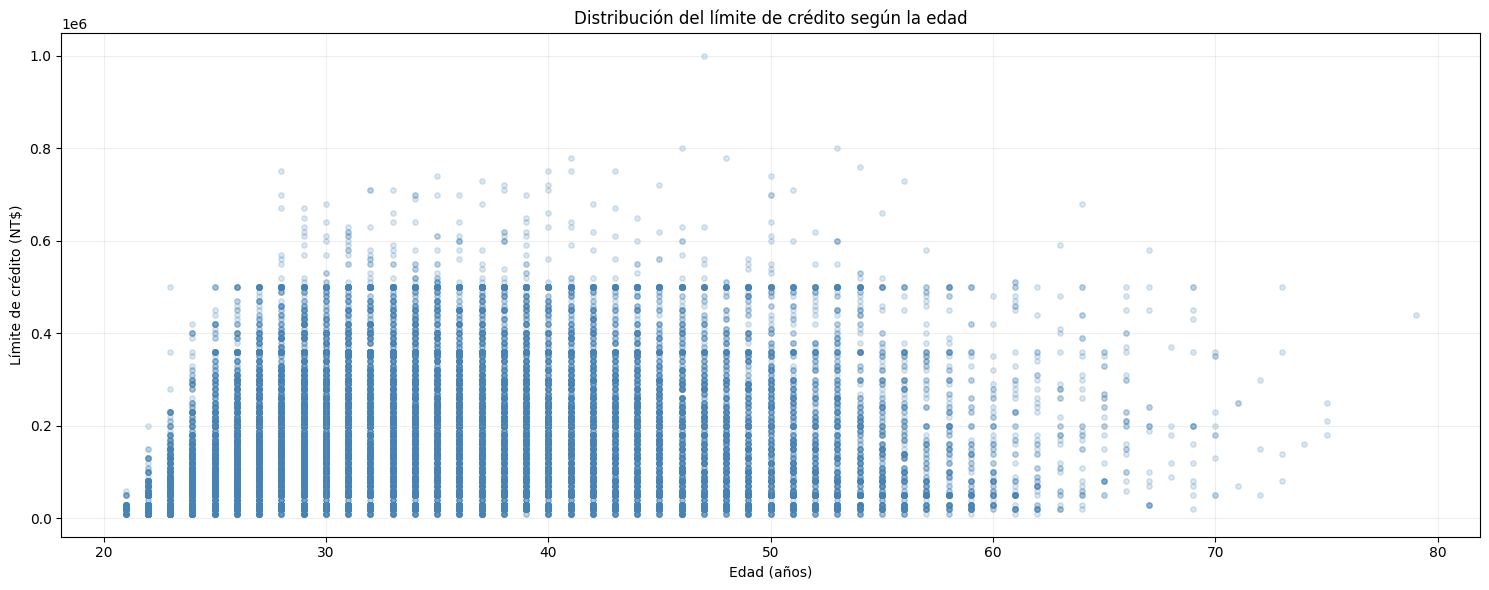

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(
    data=df_num,
    x="AGE",
    y="LIMIT_BAL",
    alpha=0.2,
    s=15,
    color="steelblue"
)

ax.set_title("Distribución del límite de crédito según la edad")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Límite de crédito (NT$)")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

##### Histograma 2D
Muestre la interacción entre las variables 'AGE' y 'LIMIT_BAL'

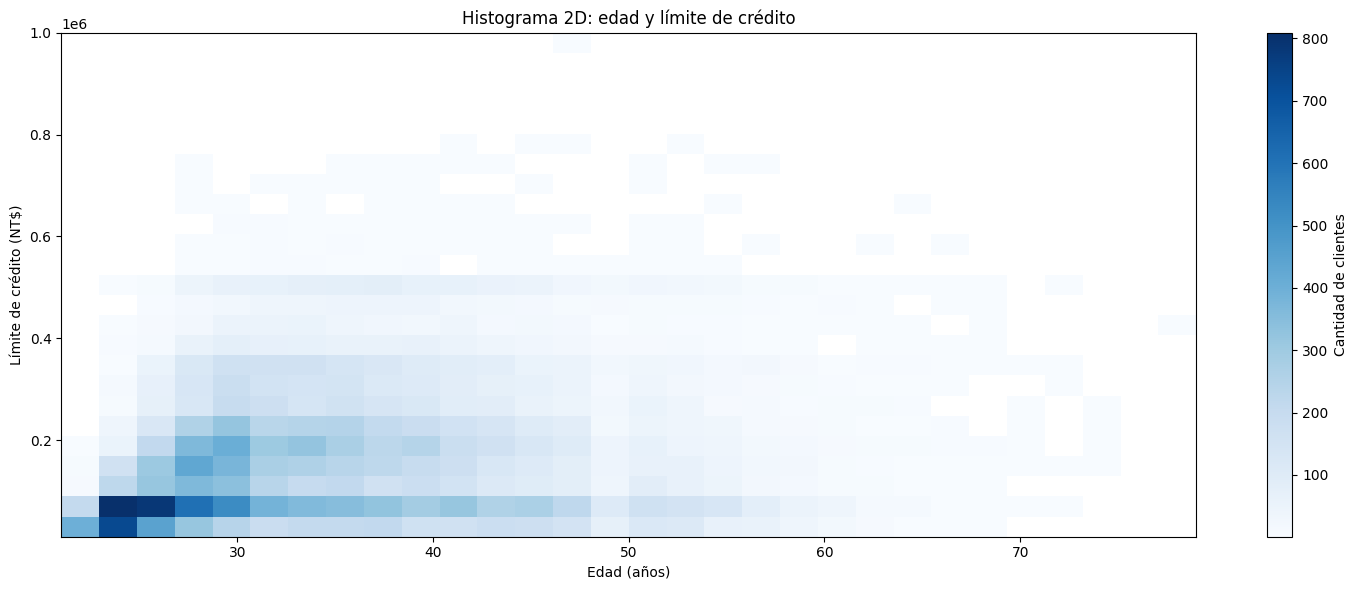

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

histograma = ax.hist2d(
    data=df_num,
    x="AGE",
    y="LIMIT_BAL",
    bins=(30, 25),
    cmap="Blues",
    cmin=1
)

fig.colorbar(histograma[3], ax=ax, label="Cantidad de clientes")

ax.set_title("Histograma 2D: edad y límite de crédito")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Límite de crédito (NT$)")

plt.tight_layout()
plt.show()

#### Gráficos de Categoricas vs Numéricas

##### Scatterplot

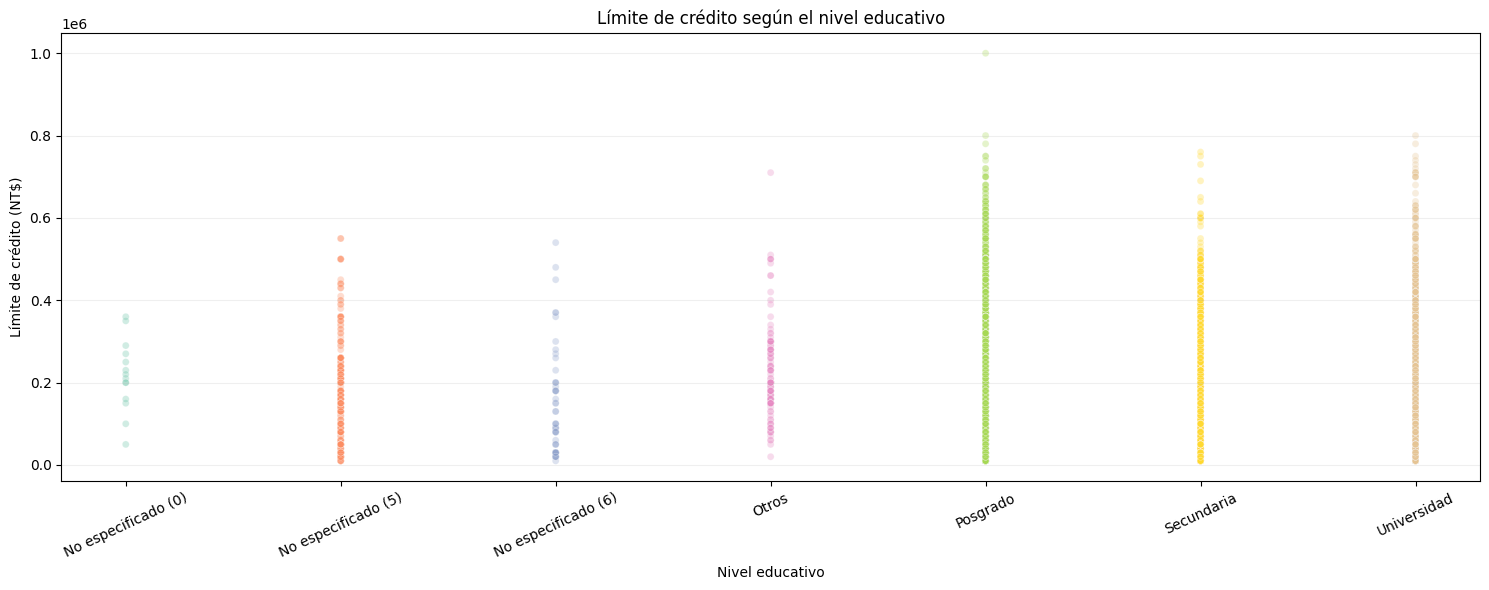

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_cat_num = pd.concat([df_cat_etiquetado, df_num], axis=1)

fig, ax = plt.subplots(figsize=(15, 6))

sns.scatterplot(
    data=df_cat_num,
    x="EDUCATION",
    y="LIMIT_BAL",
    hue="EDUCATION",
    alpha=0.3,
    s=25,
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title("Límite de crédito según el nivel educativo")
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Límite de crédito (NT$)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

##### Stripplot
Mejorando la visualización (apelotonamiento)
* Cambio de scatterplot por stripplot

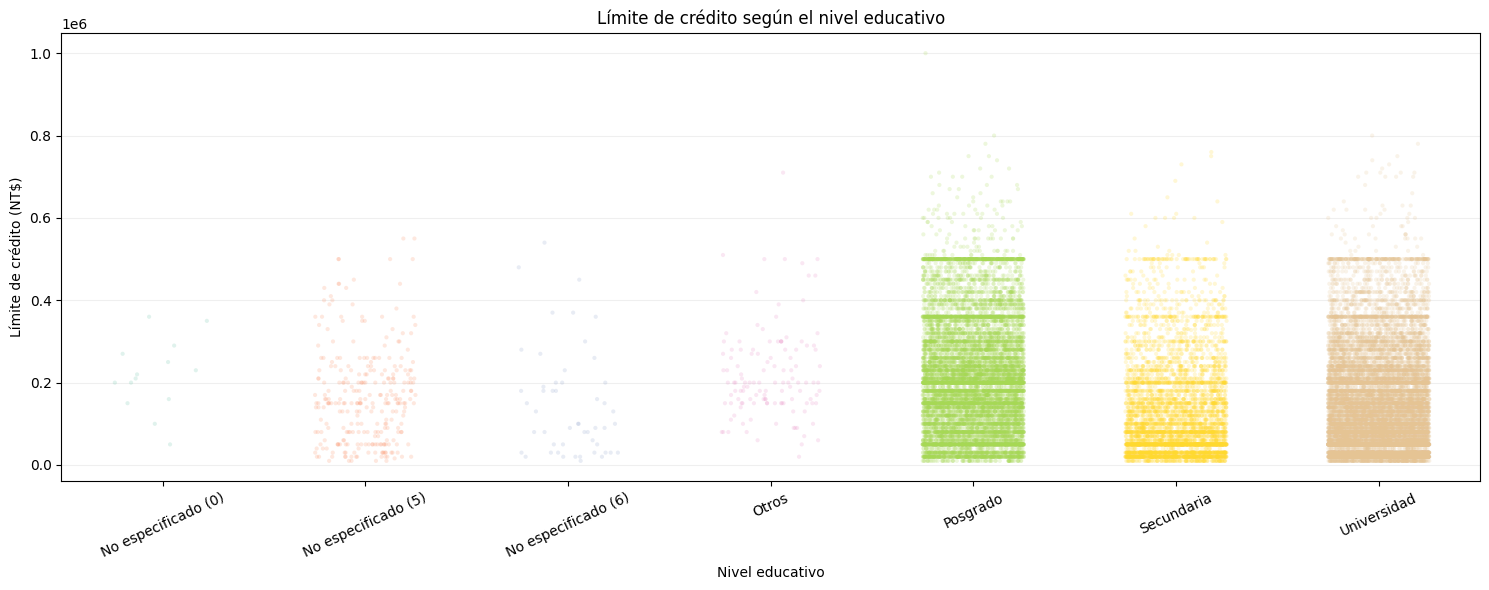

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(15, 6))

sns.stripplot(
    data=df_cat_num,
    x="EDUCATION",
    y="LIMIT_BAL",
    hue="EDUCATION",
    jitter=0.25,
    alpha=0.2,
    size=3,
    palette="Set2",
    legend=False,
    ax=ax
)

ax.set_title("Límite de crédito según el nivel educativo")
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Límite de crédito (NT$)")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### Correlación

##### Matrices de correlación

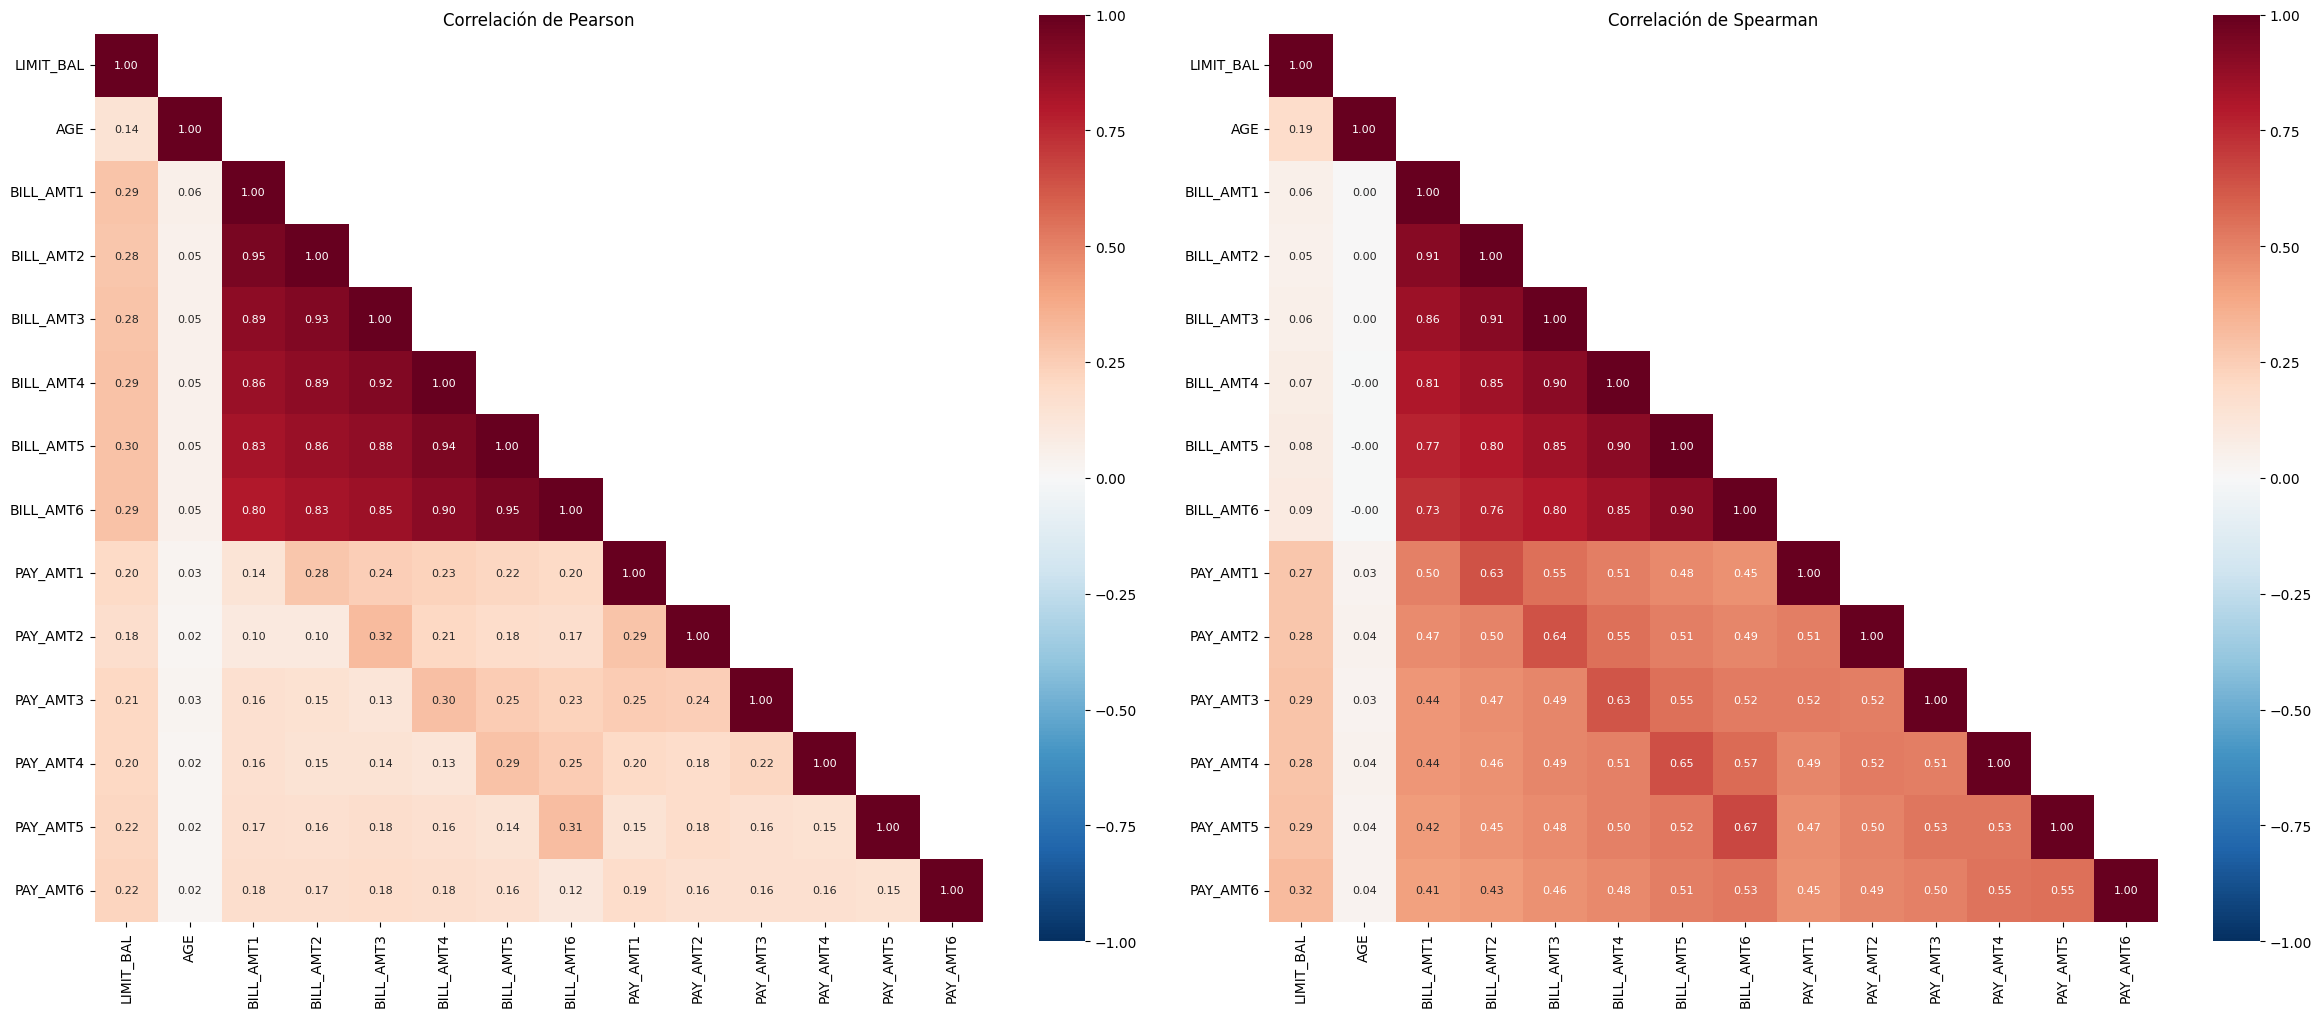

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_pearson = df_num.corr(method="pearson")
corr_spearman = df_num.corr(method="spearman")

# Ocultar la parte superior para evitar información repetida
mascara = np.triu(
    np.ones_like(corr_pearson, dtype=bool),
    k=1
)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, matriz, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Correlación de Pearson", "Correlación de Spearman"]
):
    sns.heatmap(
        matriz,
        mask=mascara,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        annot_kws={"size": 8},
        ax=ax
    )

    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

Para interpretar los valores:
- Cerca de 1: cuando una variable aumenta, la otra también tiende a aumentar.
- Cerca de -1: cuando una aumenta, la otra tiende a disminuir.
- Cerca de 0: hay poca relación del tipo que mide ese método; todavía puede existir otra relación más compleja.

##### Parejas con mayor correlación

In [ ]:
mascara_pares = np.triu(
    np.ones_like(corr_spearman, dtype=bool),
    k=1
)

pares = (
    corr_spearman
    .where(mascara_pares)
    .stack()
    .reset_index()
)

pares.columns = ["Variable_1", "Variable_2", "Correlacion"]

pares["Correlacion_absoluta"] = pares["Correlacion"].abs()

pares = pares.sort_values(
    "Correlacion_absoluta",
    ascending=False
)

display(
    pares[["Variable_1", "Variable_2", "Correlacion"]]
    .head(15)
    .round(3)
)

,Variable_1,Variable_2,Correlacion
25,BILL_AMT1,BILL_AMT2,0.911
36,BILL_AMT2,BILL_AMT3,0.908
46,BILL_AMT3,BILL_AMT4,0.903
55,BILL_AMT4,BILL_AMT5,0.903
63,BILL_AMT5,BILL_AMT6,0.902
26,BILL_AMT1,BILL_AMT3,0.857
47,BILL_AMT3,BILL_AMT5,0.848
37,BILL_AMT2,BILL_AMT4,0.848
56,BILL_AMT4,BILL_AMT6,0.848
27,BILL_AMT1,BILL_AMT4,0.807


##### Correlación de cada variable numérica con el objetivo

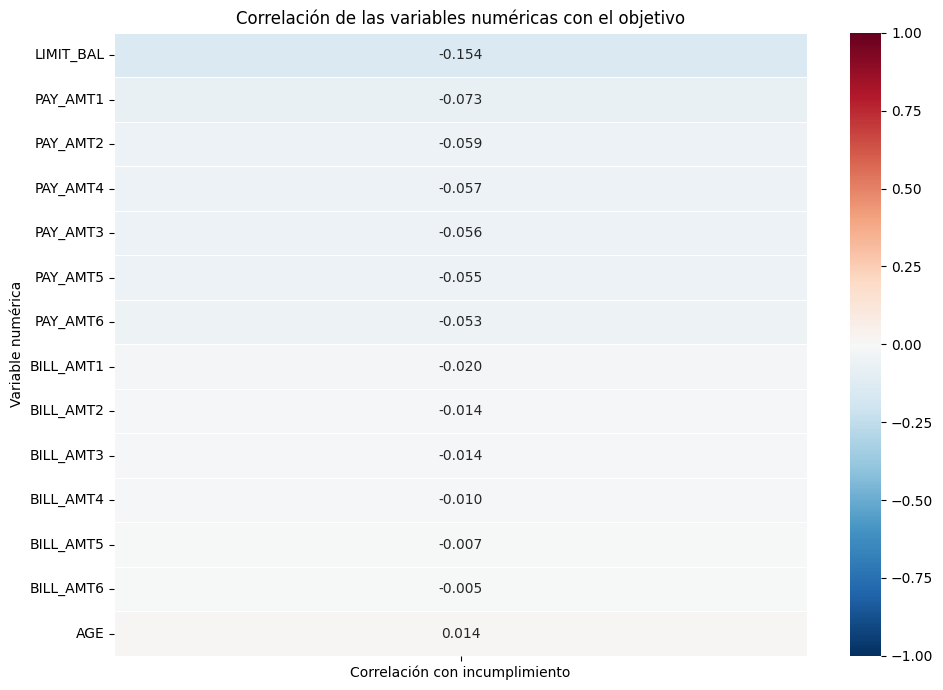

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target = "default payment next month"

df_correlacion = df_num.copy()
df_correlacion[target] = df[target].astype(int)

corr_target = (
    df_correlacion
    .corr(method="pearson")[target]
    .drop(target)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_target.to_frame(name="Correlación con incumplimiento"),
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlación de las variables numéricas con el objetivo")
ax.set_ylabel("Variable numérica")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

##### Correlación con variables categóticas con la variable tarjet

In [ ]:
import pandas as pd

# Detectar el nombre de la variable objetivo
target = (
    "default_payment_next_month"
    if "default_payment_next_month" in df.columns
    else "default payment next month"
)

# Excluir el objetivo de las variables que vamos a analizar
columnas_cat = [
    columna for columna in df_cat_etiquetado.columns
    if columna not in [
        "default_payment_next_month",
        "default payment next month"
    ]
]

# Verificar que cada fila corresponda al mismo cliente
assert df_cat_etiquetado.index.equals(df.index), \
    "Los índices de ambos DataFrames deben coincidir."

datos = df_cat_etiquetado[columnas_cat].copy()
datos["objetivo"] = df[target].astype(int)

resumenes = {}

for columna in columnas_cat:
    resumen = (
        datos.groupby(columna, observed=True)["objetivo"]
        .agg(clientes="count", incumplimientos="sum")
    )

    resumen["porcentaje_incumplimiento"] = (
        resumen["incumplimientos"] / resumen["clientes"] * 100
    )

    resumenes[columna] = resumen

porcentaje_general = datos["objetivo"].mean() * 100

display(resumenes["EDUCATION"].round(2))

,clientes,incumplimientos,porcentaje_incumplimiento
EDUCATION,,,
No especificado (0),14,0,0.00
No especificado (5),280,18,6.43
No especificado (6),51,8,15.69
Otros,123,7,5.69
Posgrado,10563,2032,19.24
Secundaria,4915,1237,25.17
Universidad,14019,3328,23.74


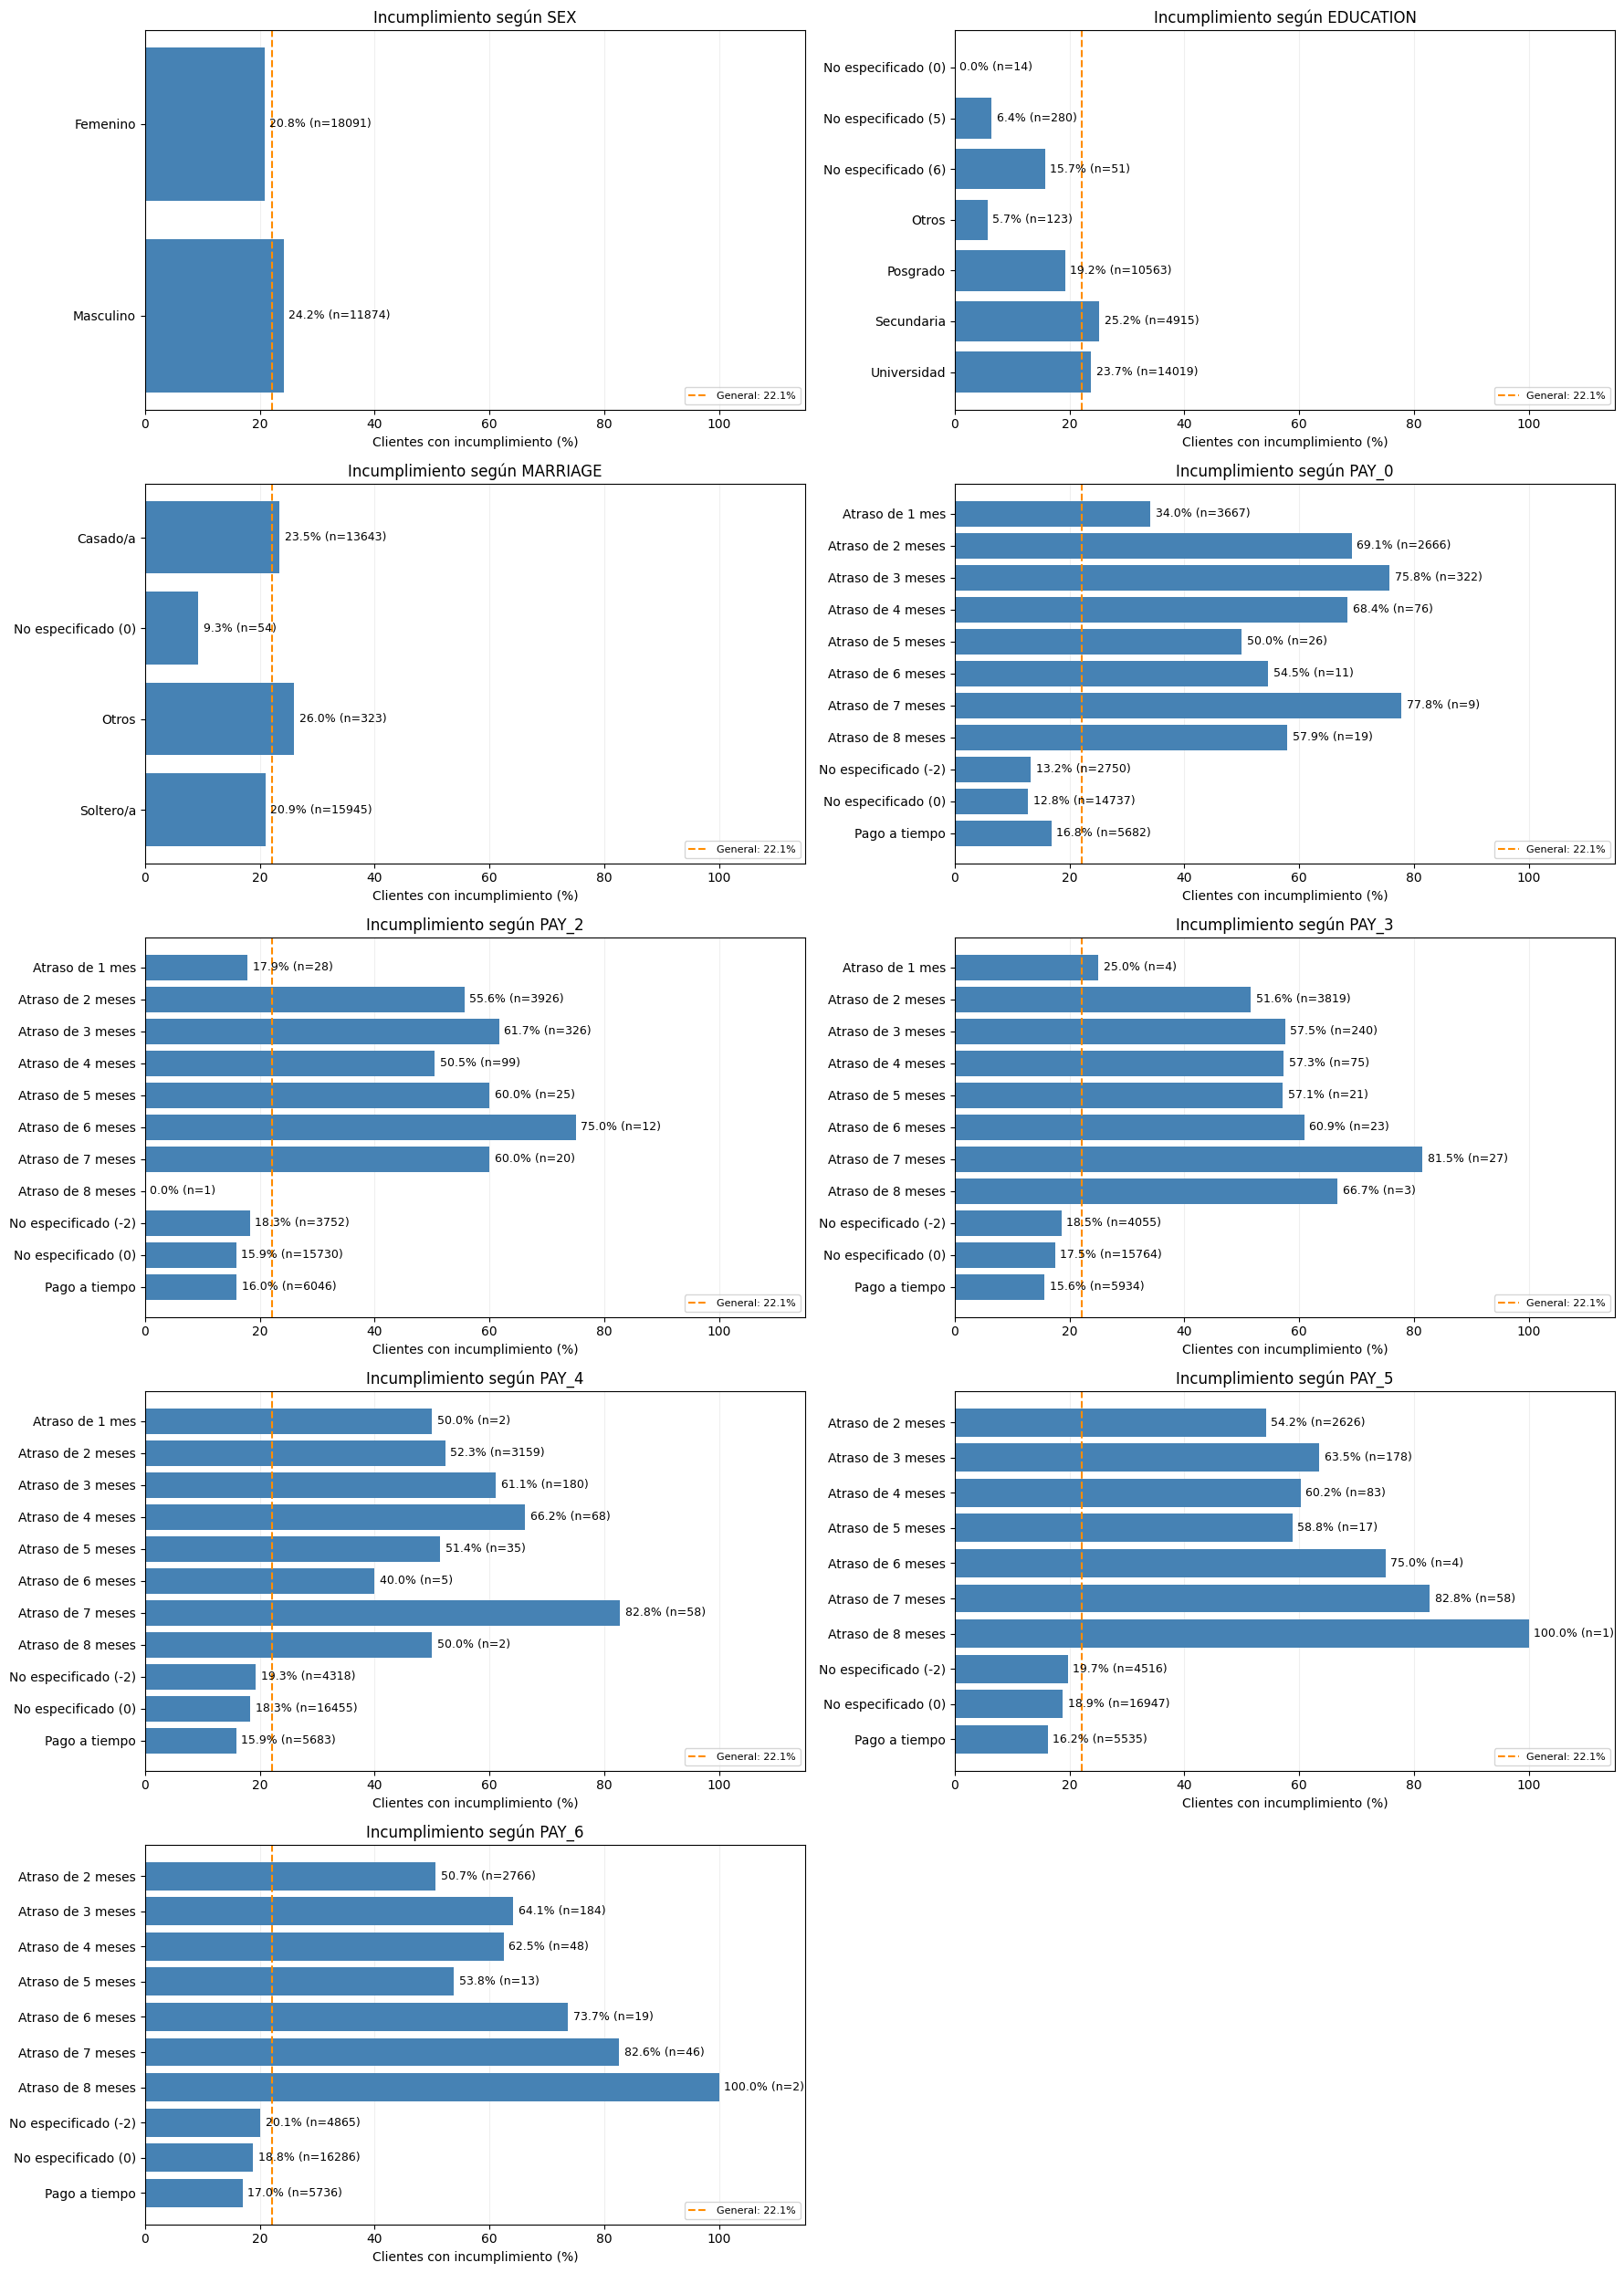

In [ ]:
import matplotlib.pyplot as plt
import math

n_columnas = 2
n_filas = math.ceil(len(columnas_cat) / n_columnas)

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(18, 5 * n_filas),
    squeeze=False
)

axes = axes.flatten()

for ax, columna in zip(axes, columnas_cat):
    resumen = resumenes[columna]

    barras = ax.barh(
        resumen.index.astype(str),
        resumen["porcentaje_incumplimiento"],
        color="steelblue"
    )

    etiquetas = [
        f"{porcentaje:.1f}% (n={cantidad})"
        for porcentaje, cantidad in zip(
            resumen["porcentaje_incumplimiento"],
            resumen["clientes"]
        )
    ]

    ax.bar_label(barras, labels=etiquetas, padding=4, fontsize=9)

    ax.axvline(
        porcentaje_general,
        color="darkorange",
        linestyle="--",
        label=f"General: {porcentaje_general:.1f}%"
    )

    ax.set_title(f"Incumplimiento según {columna}")
    ax.set_xlabel("Clientes con incumplimiento (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 115)
    ax.set_xticks(range(0, 101, 20))
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=8)

for ax in axes[len(columnas_cat):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Data Transformation

In [ ]:
df_cat_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   SEX                         29965 non-null  category
 1   EDUCATION                   29965 non-null  category
 2   MARRIAGE                    29965 non-null  category
 3   PAY_0                       29965 non-null  category
 4   PAY_2                       29965 non-null  category
 5   PAY_3                       29965 non-null  category
 6   PAY_4                       29965 non-null  category
 7   PAY_5                       29965 non-null  category
 8   PAY_6                       29965 non-null  category
 9   default payment next month  29965 non-null  category
 10  LIMIT_BAL                   29965 non-null  int64   
 11  AGE                         29965 non-null  int64   
 12  BILL_AMT1                   29965 non-null  int64   
 13  BILL_AMT2            

Dividimos en categóricas y numéricas

In [ ]:
df_cat = df_cat_num.select_dtypes(exclude='number').copy()
df_num = df_cat_num.select_dtypes(include='number').copy()

### Transformación Variables categóricas (One hot encoding)

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Variables categóricas predictoras: no incluimos la variable tarjet
columnas = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

display(df_cat[columnas].head())

# Convertir las categorías en columnas binarias
oneHE = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore",
    dtype="int64"
)

valores_oneHE = oneHE.fit_transform(df_cat[columnas])

# Conservar los índices para unir después los datos correctamente
df_oneHE = pd.DataFrame(
    data=valores_oneHE,
    columns=oneHE.get_feature_names_out(columnas),
    index=df_cat.index
)

display(df_oneHE.head())

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
0,Femenino,Universidad,Casado/a,Atraso de 2 meses,Atraso de 2 meses,Pago a tiempo,Pago a tiempo,No especificado (-2),No especificado (-2)
1,Femenino,Universidad,Soltero/a,Pago a tiempo,Atraso de 2 meses,No especificado (0),No especificado (0),No especificado (0),Atraso de 2 meses
2,Femenino,Universidad,Soltero/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0)
3,Femenino,Universidad,Casado/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0)
4,Masculino,Universidad,Casado/a,Pago a tiempo,No especificado (0),Pago a tiempo,No especificado (0),No especificado (0),No especificado (0)


,SEX_Masculino,EDUCATION_No especificado (5),EDUCATION_No especificado (6),EDUCATION_Otros,EDUCATION_Posgrado,EDUCATION_Secundaria,EDUCATION_Universidad,MARRIAGE_No especificado (0),MARRIAGE_Otros,MARRIAGE_Soltero/a,...,PAY_5_Pago a tiempo,PAY_6_Atraso de 3 meses,PAY_6_Atraso de 4 meses,PAY_6_Atraso de 5 meses,PAY_6_Atraso de 6 meses,PAY_6_Atraso de 7 meses,PAY_6_Atraso de 8 meses,PAY_6_No especificado (-2),PAY_6_No especificado (0),PAY_6_Pago a tiempo
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


**Nota:** Se utiliza One-Hot Encoding para las variables categóricas. No se aplica Ordinal Encoding porque las variables con orden parcial contienen categorías adicionales cuya posición no está definida en la documentación.

### Transformación Variables numéricas (Min-Max Scaling)

In [ ]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  29965 non-null  int64
 1   AGE        29965 non-null  int64
 2   BILL_AMT1  29965 non-null  int64
 3   BILL_AMT2  29965 non-null  int64
 4   BILL_AMT3  29965 non-null  int64
 5   BILL_AMT4  29965 non-null  int64
 6   BILL_AMT5  29965 non-null  int64
 7   BILL_AMT6  29965 non-null  int64
 8   PAY_AMT1   29965 non-null  int64
 9   PAY_AMT2   29965 non-null  int64
 10  PAY_AMT3   29965 non-null  int64
 11  PAY_AMT4   29965 non-null  int64
 12  PAY_AMT5   29965 non-null  int64
 13  PAY_AMT6   29965 non-null  int64
dtypes: int64(14)
memory usage: 3.4 MB


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

columnas = df_num.columns.tolist()

mms = MinMaxScaler()
mms.fit(df_num[columnas])

valores_escalados = mms.transform(df_num[columnas])

df_mms = pd.DataFrame(
    data=valores_escalados,
    columns=columnas,
    index=df_num.index
)

display(df_mms.head())

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,0.010101,0.051724,0.149982,0.069164,0.086723,0.160138,0.080648,0.260979,0.000000,0.000409,0.000000,0.000000,0.000000,0.000000
1,0.111111,0.086207,0.148892,0.067858,0.087817,0.163220,0.084074,0.263485,0.000000,0.000594,0.001116,0.001610,0.000000,0.003783
2,0.080808,0.224138,0.172392,0.079532,0.093789,0.173637,0.095470,0.272928,0.001738,0.000891,0.001116,0.001610,0.002345,0.009458
3,0.040404,0.275862,0.188100,0.111995,0.113407,0.186809,0.109363,0.283685,0.002290,0.001199,0.001339,0.001771,0.002506,0.001892
4,0.040404,0.620690,0.154144,0.071601,0.106020,0.179863,0.099633,0.275681,0.002290,0.021779,0.011160,0.014493,0.001615,0.001284


### Variable target

In [ ]:
df_target= df['default payment next month']
df_target

,default payment next month
0,1
1,1
2,0
3,0
4,0
...,...
29995,0
29996,0
29997,1
29998,1


### Unimos todos los dataframe en uno solo

In [ ]:
df_final = pd.concat([df_oneHE,df_mms,df_target],axis=1)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   SEX_Masculino                  29965 non-null  int64   
 1   EDUCATION_No especificado (5)  29965 non-null  int64   
 2   EDUCATION_No especificado (6)  29965 non-null  int64   
 3   EDUCATION_Otros                29965 non-null  int64   
 4   EDUCATION_Posgrado             29965 non-null  int64   
 5   EDUCATION_Secundaria           29965 non-null  int64   
 6   EDUCATION_Universidad          29965 non-null  int64   
 7   MARRIAGE_No especificado (0)   29965 non-null  int64   
 8   MARRIAGE_Otros                 29965 non-null  int64   
 9   MARRIAGE_Soltero/a             29965 non-null  int64   
 10  PAY_0_Atraso de 2 meses        29965 non-null  int64   
 11  PAY_0_Atraso de 3 meses        29965 non-null  int64   
 12  PAY_0_Atraso de 4 meses        29965 

### Verificamos los resultados

In [ ]:
target = "default payment next month"

df_target = df[target].astype(int)

assert df_oneHE.index.equals(df_mms.index), \
    "Los índices de las variables categóricas y numéricas no coinciden."

assert df_oneHE.index.equals(df_target.index), \
    "Los índices de las predictoras y el objetivo no coinciden."

# Unir los datos
df_final = pd.concat(
    [df_oneHE, df_mms, df_target],
    axis=1
)

display(df_final.head())

print("Dimensiones:", df_final.shape)
print("Valores nulos:", df_final.isna().sum().sum())

,SEX_Masculino,EDUCATION_No especificado (5),EDUCATION_No especificado (6),EDUCATION_Otros,EDUCATION_Posgrado,EDUCATION_Secundaria,EDUCATION_Universidad,MARRIAGE_No especificado (0),MARRIAGE_Otros,MARRIAGE_Soltero/a,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,0,0,0,0,0,0,1,0,0,0,...,0.160138,0.080648,0.260979,0.000000,0.000409,0.000000,0.000000,0.000000,0.000000,1
1,0,0,0,0,0,0,1,0,0,1,...,0.163220,0.084074,0.263485,0.000000,0.000594,0.001116,0.001610,0.000000,0.003783,1
2,0,0,0,0,0,0,1,0,0,1,...,0.173637,0.095470,0.272928,0.001738,0.000891,0.001116,0.001610,0.002345,0.009458,0
3,0,0,0,0,0,0,1,0,0,0,...,0.186809,0.109363,0.283685,0.002290,0.001199,0.001339,0.001771,0.002506,0.001892,0
4,1,0,0,0,0,0,1,0,0,0,...,0.179863,0.099633,0.275681,0.002290,0.021779,0.011160,0.014493,0.001615,0.001284,0


Dimensiones: (29965, 83)
Valores nulos: 0


# Modeling

### Modelo ML - Regresión logística

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

target = (
    "default_payment_next_month"
    if "default_payment_next_month" in df.columns
    else "default payment next month"
)

columnas_cat = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

columnas_num = (
    ["LIMIT_BAL", "AGE"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
)

X = df[columnas_cat + columnas_num].copy()
y = df[target].astype(int)

assert set(y.unique()) == {0, 1}, \
    "La variable objetivo debe contener únicamente 0 y 1."

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (23972, 23)
Prueba: (5993, 23)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.dummy import DummyClassifier

def crear_pipeline(estimador, escalar=False):
    preprocesamiento = ColumnTransformer(
        transformers=[
            (
                "categoricas",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                    drop=None
                ),
                columnas_cat
            ),
            (
                "numericas",
                MinMaxScaler() if escalar else "passthrough",
                columnas_num
            )
        ]
    )

    return Pipeline([
        ("preprocesamiento", preprocesamiento),
        ("modelo", estimador)
    ])

modelos = {
    "Referencia Dummy": crear_pipeline(
        DummyClassifier(strategy="prior")
    ),

    "Regresión logística": crear_pipeline(
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=42
        ),
        escalar=True
    ),

    "Árbol de decisiones": crear_pipeline(
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=30,
            random_state=42
        )
    ),

    "Random Forest": crear_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=1
        )
    ),

    "Gradient Boosting": crear_pipeline(
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
}

In [ ]:
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "Accuracy": "accuracy",
    "Precision": make_scorer(
        precision_score, zero_division=0
    ),
    "Recall": make_scorer(
        recall_score, zero_division=0
    ),
    "Especificidad": make_scorer(
        recall_score, pos_label=0, zero_division=0
    ),
    "F1": make_scorer(
        f1_score, zero_division=0
    ),
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

resultados = []

for nombre, modelo in modelos.items():
    print(f"Evaluando: {nombre}")

    evaluacion = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring=metricas,
        n_jobs=-1,
        error_score="raise"
    )

    fila = {"Modelo": nombre}

    for metrica in metricas:
        fila[metrica] = evaluacion[f"test_{metrica}"].mean()

    fila["AP_desviacion"] = evaluacion["test_AP"].std()
    resultados.append(fila)

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values("AP", ascending=False)
    .reset_index(drop=True)
)

display(resultados_df.round(4))

Evaluando: Referencia Dummy
Evaluando: Regresión logística
Evaluando: Árbol de decisiones
Evaluando: Random Forest
Evaluando: Gradient Boosting


,Modelo,Accuracy,Precision,Recall,Especificidad,F1,ROC_AUC,AP,AP_desviacion
0,Random Forest,0.8190,0.6711,0.3578,0.9501,0.4667,0.7829,0.5592,0.0110
1,Gradient Boosting,0.8200,0.6838,0.3475,0.9543,0.4607,0.7813,0.5547,0.0149
2,Regresión logística,0.8205,0.6798,0.3571,0.9522,0.4682,0.7668,0.5411,0.0175
3,Árbol de decisiones,0.8172,0.6829,0.3256,0.9569,0.4405,0.7514,0.5008,0.0097
4,Referencia Dummy,0.7787,0.0000,0.0000,1.0000,0.0000,0.5000,0.2213,0.0001


In [ ]:
from sklearn.base import clone

nombre_elegido = resultados_df.iloc[0]["Modelo"]

modelo_final = clone(modelos[nombre_elegido])

modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

indice_clase_1 = list(modelo_final.classes_).index(1)
y_proba = modelo_final.predict_proba(X_test)[:, indice_clase_1]

matriz = confusion_matrix(y_test, y_pred, labels=[0, 1])
TN, FP, FN, TP = matriz.ravel()

print("Modelo elegido:", nombre_elegido)

display(pd.DataFrame(
    matriz,
    columns=["Predicción: no incumple", "Predicción: incumple"],
    index=["Real: no incumple", "Real: incumple"]
))

resultados_prueba = pd.DataFrame([{
    "Modelo": nombre_elegido,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "Especificidad": TN / (TN + FP) if (TN + FP) else np.nan,
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba),
    "AP": average_precision_score(y_test, y_proba)
}])

display(resultados_prueba.round(4))

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Sin incumplimiento", "Con incumplimiento"],
    zero_division=0
))

Modelo elegido: Random Forest


,Predicción: no incumple,Predicción: incumple
Real: no incumple,4437,230
Real: incumple,859,467


,Modelo,Accuracy,Precision,Recall,Especificidad,F1,ROC_AUC,AP
0,Random Forest,0.8183,0.67,0.3522,0.9507,0.4617,0.7743,0.5534


                    precision    recall  f1-score   support

Sin incumplimiento       0.84      0.95      0.89      4667
Con incumplimiento       0.67      0.35      0.46      1326

          accuracy                           0.82      5993
         macro avg       0.75      0.65      0.68      5993
      weighted avg       0.80      0.82      0.80      5993



# Optimization

### Hiperparámetros

Bloque 1: definir los hiperparámetros

In [ ]:
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

rf_base = clone(modelos["Random Forest"])
rf_base.set_params(modelo__n_jobs=1)

parametros_rf = {
    "modelo__n_estimators": [200, 400],
    "modelo__max_depth": [None, 8, 15, 25],
    "modelo__min_samples_split": [2, 10, 20],
    "modelo__min_samples_leaf": [1, 5, 10, 20],
    "modelo__max_features": ["sqrt", 0.5],
    "modelo__class_weight": [None, "balanced"]
}

En este bloque se crea una copia del modelo Random Forest y se definen los hiperparámetros que se explorarán, como la cantidad de árboles, su profundidad y el mínimo de registros por hoja. También se probará dar mayor peso a la clase menos frecuente para evaluar su efecto en las predicciones.

Bloque 2: ejecutar la búsqueda

In [ ]:
cv_rf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_rf = {
    "AP": "average_precision",
    "ROC_AUC": "roc_auc",
    "Accuracy": "accuracy",
    "Precision": make_scorer(
        precision_score, zero_division=0
    ),
    "Recall": make_scorer(
        recall_score, zero_division=0
    ),
    "F1": make_scorer(
        f1_score, zero_division=0
    ),
    "Especificidad": make_scorer(
        recall_score, pos_label=0, zero_division=0
    )
}

busqueda_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=parametros_rf,
    n_iter=20,
    scoring=metricas_rf,
    refit="AP",
    cv=cv_rf,
    random_state=42,
    n_jobs=-1,
    pre_dispatch="n_jobs",
    verbose=1,
    return_train_score=False,
    error_score="raise"
)

busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(busqueda_rf.best_params_)

print(
    "\nMejor AP promedio en validación:",
    round(busqueda_rf.best_score_, 4)
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros:
{'modelo__n_estimators': 200, 'modelo__min_samples_split': 10, 'modelo__min_samples_leaf': 20, 'modelo__max_features': 0.5, 'modelo__max_depth': 15, 'modelo__class_weight': 'balanced'}

Mejor AP promedio en validación: 0.56


Se utiliza RandomizedSearchCV para evaluar 20 combinaciones de hiperparámetros mediante validación cruzada de cinco particiones, utilizando únicamente los datos de entrenamiento. Se selecciona la combinación con mayor Average Precision (AP) promedio y se entrena nuevamente con todo el conjunto de entrenamiento.

Bloque 3: revisar las mejores combinaciones

In [ ]:
tabla_busqueda = pd.DataFrame(busqueda_rf.cv_results_)

columnas_resultado = [
    "rank_test_AP",
    "mean_test_AP",
    "std_test_AP",
    "mean_test_ROC_AUC",
    "mean_test_Accuracy",
    "mean_test_Precision",
    "mean_test_Recall",
    "mean_test_F1",
    "mean_test_Especificidad",
    "params"
]

display(
    tabla_busqueda[columnas_resultado]
    .sort_values("rank_test_AP")
    .head(10)
    .round(4)
)

,rank_test_AP,mean_test_AP,std_test_AP,mean_test_ROC_AUC,mean_test_Accuracy,mean_test_Precision,mean_test_Recall,mean_test_F1,mean_test_Especificidad,params
3,1,0.5600,0.0102,0.7855,0.7850,0.5127,0.5841,0.5460,0.8421,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
14,2,0.5598,0.0105,0.7845,0.8187,0.6757,0.3488,0.4599,0.9523,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
9,3,0.5593,0.0102,0.7845,0.7852,0.5131,0.5784,0.5438,0.8440,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
16,4,0.5589,0.0117,0.7824,0.8175,0.6653,0.3537,0.4617,0.9493,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
0,5,0.5582,0.0109,0.7819,0.7756,0.4941,0.5916,0.5385,0.8278,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
5,6,0.5574,0.0091,0.7827,0.7951,0.5370,0.5402,0.5385,0.8675,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
8,7,0.5573,0.0090,0.7829,0.7961,0.5392,0.5409,0.5400,0.8685,"{'modelo__n_estimators': 400, 'modelo__min_sam..."
11,8,0.5569,0.0114,0.7855,0.8182,0.6761,0.3431,0.4551,0.9531,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
7,8,0.5569,0.0114,0.7855,0.8182,0.6761,0.3431,0.4551,0.9531,"{'modelo__n_estimators': 200, 'modelo__min_sam..."
2,10,0.5560,0.0109,0.7857,0.7792,0.5008,0.6041,0.5476,0.8290,"{'modelo__n_estimators': 400, 'modelo__min_sam..."


Se muestran las diez combinaciones con mayor AP promedio en validación cruzada. Además, se revisan métricas como precisión, recall, F1 y ROC-AUC para identificar las ventajas y limitaciones de cada configuración. La desviación de AP permite observar cuánto varían los resultados entre las particiones.

Bloque 4: comparar contra el Random Forest inicial

In [ ]:
metricas_comparar = [
    "AP", "ROC_AUC", "Accuracy",
    "Precision", "Recall", "F1", "Especificidad"
]

fila_inicial = resultados_df.loc[
    resultados_df["Modelo"].eq("Random Forest")
].iloc[0]

indice_mejor = busqueda_rf.best_index_

comparacion_rf = pd.DataFrame([
    {
        "Version": "Random Forest inicial",
        **{
            metrica: fila_inicial[metrica]
            for metrica in metricas_comparar
        }
    },
    {
        "Version": "Random Forest ajustado",
        **{
            metrica: busqueda_rf.cv_results_[
                f"mean_test_{metrica}"
            ][indice_mejor]
            for metrica in metricas_comparar
        }
    }
])

display(comparacion_rf.round(4))

modelo_rf_optimizado = busqueda_rf.best_estimator_

,Version,AP,ROC_AUC,Accuracy,Precision,Recall,F1,Especificidad
0,Random Forest inicial,0.5592,0.7829,0.819,0.6711,0.3578,0.4667,0.9501
1,Random Forest ajustado,0.5600,0.7855,0.785,0.5127,0.5841,0.5460,0.8421


Se comparan las métricas de validación cruzada del Random Forest inicial y del modelo ajustado para determinar si la búsqueda aportó una mejora. Finalmente, se conserva el modelo ajustado, junto con sus transformaciones, en la variable modelo_rf_optimizado.

# Conclusion

La búsqueda de hiperparámetros modificó el desempeño del Random Forest. El modelo ajustado aumentó el recall de 35,78 % a 58,41 % y el F1 de 0,4667 a 0,5460, lo que indica una mayor detección de incumplimientos y un mejor equilibrio entre precisión y recall. Sin embargo, la precisión y la especificidad disminuyeron, por lo que también se generan más falsas alarmas.

Las mejoras en AP y ROC-AUC fueron pequeñas. Por ello, no se concluye que el modelo ajustado sea superior en todos los aspectos. Su elección depende de la importancia de detectar incumplimientos frente al costo de señalar incorrectamente a clientes que cumplen. Estos resultados corresponden a validación cruzada y deben interpretarse considerando su variabilidad.

# Dashboard Power BI

## 1. Cargar el dataset desde Google Drive

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive

drive.mount("/content/drive")

ruta_archivo = "/content/drive/MyDrive/credit_default_prediction.xls"

# El archivo original que revisamos tiene los nombres en la segunda fila
df_original = pd.read_excel(ruta_archivo, header=0)

print("Dimensiones:", df_original.shape)
display(df_original.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Recuperar la preparación y separar los datos

In [ ]:
target = "default_payment_next_month"

df = df_original.rename(columns={
    "default payment next month": target
}).copy()

# True únicamente si antes eliminaste duplicados después de retirar ID.
# Se conserva el primer registro, igual que drop_duplicates() por defecto.
REPETIR_ELIMINACION_DUPLICADOS = True

if REPETIR_ELIMINACION_DUPLICADOS:
    columnas_sin_id = [c for c in df.columns if c != "ID"]
    df = df.drop_duplicates(subset=columnas_sin_id).copy()

columnas_cat = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

columnas_num = (
    ["LIMIT_BAL", "AGE"]
    + [f"BILL_AMT{i}" for i in range(1, 7)]
    + [f"PAY_AMT{i}" for i in range(1, 7)]
)

df[columnas_cat] = df[columnas_cat].astype("category")

X = df[columnas_cat + columnas_num].copy()
y = df[target].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Clientes:", len(df))
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Clientes: 29965
Entrenamiento: (23972, 23)
Prueba: (5993, 23)


## 3. Reconstruir el Random Forest con los mejores parámetros

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocesamiento = ColumnTransformer([
    (
        "categoricas",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop=None
        ),
        columnas_cat
    ),
    (
        "numericas",
        "passthrough",
        columnas_num
    )
])

modelo_candidato = Pipeline([
    ("preprocesamiento", preprocesamiento),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=200,
            min_samples_split=10,
            min_samples_leaf=20,
            max_features=0.5,
            max_depth=15,
            class_weight="balanced",
            random_state=42,
            n_jobs=1
        )
    )
])

nombre_modelo = "Random Forest ajustado"

## 4. Seleccionar el umbral utilizando el entrenamiento

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

cv_umbral = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

# Cada registro es predicho por un modelo que no se entrenó con él
probabilidades_oof = cross_val_predict(
    modelo_candidato,
    X_train,
    y_train,
    cv=cv_umbral,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

filas = []

for umbral in np.arange(1, 100) / 100:
    pred = (probabilidades_oof >= umbral).astype(int)

    filas.append({
        "Umbral": umbral,
        "Precision": precision_score(y_train, pred, zero_division=0),
        "Recall": recall_score(y_train, pred, zero_division=0),
        "F1": f1_score(y_train, pred, zero_division=0)
    })

tabla_umbrales = pd.DataFrame(filas)

mejor_fila = tabla_umbrales.sort_values(
    ["F1", "Precision"],
    ascending=False
).iloc[0]

umbral_final = float(mejor_fila["Umbral"])

print("Umbral elegido:", umbral_final)

display(
    tabla_umbrales[
        tabla_umbrales["Umbral"].isin([0.50, umbral_final])
    ].round(4)
)

Umbral elegido: 0.53


,Umbral,Precision,Recall,F1
49,0.50,0.5129,0.5869,0.5474
52,0.53,0.5364,0.5605,0.5482


## 5. Entrenar y obtener los resultados de prueba

In [ ]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

modelo_dashboard = clone(modelo_candidato)
modelo_dashboard.fit(X_train, y_train)

indice_positivo = list(modelo_dashboard.classes_).index(1)

probabilidades_test = modelo_dashboard.predict_proba(
    X_test
)[:, indice_positivo]

predicciones_test = (
    probabilidades_test >= umbral_final
).astype(int)

matriz = confusion_matrix(
    y_test, predicciones_test, labels=[0, 1]
)

TN, FP, FN, TP = matriz.ravel()

metricas_prueba_final = pd.DataFrame([{
    "Modelo": nombre_modelo,
    "Evaluacion": "Prueba",
    "Origen_metricas": "Calculadas en esta ejecución",
    "Umbral": umbral_final,
    "Accuracy": accuracy_score(y_test, predicciones_test),
    "Precision": precision_score(
        y_test, predicciones_test, zero_division=0
    ),
    "Recall": recall_score(
        y_test, predicciones_test, zero_division=0
    ),
    "F1": f1_score(y_test, predicciones_test, zero_division=0),
    "Especificidad": TN / (TN + FP),
    "ROC_AUC": roc_auc_score(y_test, probabilidades_test),
    "AP": average_precision_score(y_test, probabilidades_test)
}])

display(metricas_prueba_final.round(4))

display(pd.DataFrame(
    matriz,
    index=["Real: sin incumplimiento", "Real: con incumplimiento"],
    columns=["Predicción: sin incumplimiento", "Predicción: con incumplimiento"]
))

,Modelo,Evaluacion,Origen_metricas,Umbral,Accuracy,Precision,Recall,F1,Especificidad,ROC_AUC,AP
0,Random Forest ajustado,Prueba,Calculadas en esta ejecución,0.53,0.7919,0.5291,0.5422,0.5356,0.8629,0.7733,0.5492


,Predicción: sin incumplimiento,Predicción: con incumplimiento
Real: sin incumplimiento,4027,640
Real: con incumplimiento,607,719


## 6. Preparar los tres archivos para Power BI

In [ ]:
# ---------- Archivo 1: clientes ----------

assert df["ID"].is_unique
assert df["ID"].notna().all()

clientes_export = df[
    ["ID"] + columnas_cat + columnas_num + [target]
].copy()

clientes_export["Resultado_real"] = clientes_export[target].map({
    0: "Sin incumplimiento",
    1: "Con incumplimiento"
})

# Etiquetas para mostrar en Power BI, conservando los códigos originales
mapas = {
    "SEX": {
        1: "Masculino", 2: "Femenino"
    },
    "EDUCATION": {
        0: "No especificado (0)",
        1: "Posgrado",
        2: "Universidad",
        3: "Secundaria",
        4: "Otros",
        5: "No especificado (5)",
        6: "No especificado (6)"
    },
    "MARRIAGE": {
        0: "No especificado (0)",
        1: "Casado/a",
        2: "Soltero/a",
        3: "Otros"
    }
}

mapa_pagos = {
    -2: "No especificado (-2)",
    -1: "Pago a tiempo",
    0: "No especificado (0)",
    1: "Atraso de 1 mes",
    **{i: f"Atraso de {i} meses" for i in range(2, 9)},
    9: "Atraso de 9 meses o más"
}

for columna in columnas_cat:
    mapa = mapas.get(columna, mapa_pagos)
    clientes_export[f"{columna}_etiqueta"] = (
        df[columna].astype(object).map(mapa)
    )

# ---------- Archivo 2: predicciones de prueba ----------

assert X_test.index.equals(y_test.index)

predicciones_export = pd.DataFrame({
    "ID": df.loc[X_test.index, "ID"].to_numpy(),
    "Modelo": nombre_modelo,
    "Conjunto": "Prueba",
    "Real": y_test.to_numpy(),
    "Probabilidad_incumplimiento": probabilidades_test,
    "Umbral": umbral_final,
    "Prediccion": predicciones_test
})

predicciones_export["Tipo_resultado"] = [
    {
        (0, 0): "Verdadero negativo",
        (0, 1): "Falso positivo",
        (1, 0): "Falso negativo",
        (1, 1): "Verdadero positivo"
    }[(real, pred)]
    for real, pred in zip(
        predicciones_export["Real"],
        predicciones_export["Prediccion"]
    )
]

# ---------- Archivo 3: comparación de modelos ----------

# Valores redondeados recuperados de tu captura
comparacion_export = pd.DataFrame([
    {
        "Modelo": "Random Forest inicial",
        "Evaluacion": "Validación cruzada inicial",
        "Origen_metricas": "Captura anterior; valores redondeados",
        "Umbral": 0.50,
        "Accuracy": 0.8190,
        "Precision": 0.6711,
        "Recall": 0.3578,
        "F1": 0.4667,
        "Especificidad": 0.9501,
        "ROC_AUC": 0.7829,
        "AP": 0.5592
    },
    {
        "Modelo": "Random Forest ajustado",
        "Evaluacion": "Validación cruzada de búsqueda",
        "Origen_metricas": "Captura anterior; valores redondeados",
        "Umbral": 0.50,
        "Accuracy": 0.7850,
        "Precision": 0.5127,
        "Recall": 0.5841,
        "F1": 0.5460,
        "Especificidad": 0.8421,
        "ROC_AUC": 0.7855,
        "AP": 0.5600
    }
])

comparacion_export = pd.concat(
    [comparacion_export, metricas_prueba_final],
    ignore_index=True
)

# Comprobar la relación entre clientes y predicciones
assert predicciones_export["ID"].is_unique
assert predicciones_export["ID"].isin(clientes_export["ID"]).all()

display(clientes_export.head())
display(predicciones_export.head())
display(comparacion_export.round(4))

,ID,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,Resultado_real,SEX_etiqueta,EDUCATION_etiqueta,MARRIAGE_etiqueta,PAY_0_etiqueta,PAY_2_etiqueta,PAY_3_etiqueta,PAY_4_etiqueta,PAY_5_etiqueta,PAY_6_etiqueta
0,1,2,2,1,2,2,-1,-1,-2,-2,...,Con incumplimiento,Femenino,Universidad,Casado/a,Atraso de 2 meses,Atraso de 2 meses,Pago a tiempo,Pago a tiempo,No especificado (-2),No especificado (-2)
1,2,2,2,2,-1,2,0,0,0,2,...,Con incumplimiento,Femenino,Universidad,Soltero/a,Pago a tiempo,Atraso de 2 meses,No especificado (0),No especificado (0),No especificado (0),Atraso de 2 meses
2,3,2,2,2,0,0,0,0,0,0,...,Sin incumplimiento,Femenino,Universidad,Soltero/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0)
3,4,2,2,1,0,0,0,0,0,0,...,Sin incumplimiento,Femenino,Universidad,Casado/a,No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0),No especificado (0)
4,5,1,2,1,-1,0,-1,0,0,0,...,Sin incumplimiento,Masculino,Universidad,Casado/a,Pago a tiempo,No especificado (0),Pago a tiempo,No especificado (0),No especificado (0),No especificado (0)


,ID,Modelo,Conjunto,Real,Probabilidad_incumplimiento,Umbral,Prediccion,Tipo_resultado
0,8688,Random Forest ajustado,Prueba,0,0.274637,0.53,0,Verdadero negativo
1,24202,Random Forest ajustado,Prueba,0,0.164255,0.53,0,Verdadero negativo
2,27783,Random Forest ajustado,Prueba,0,0.307433,0.53,0,Verdadero negativo
3,14948,Random Forest ajustado,Prueba,0,0.344579,0.53,0,Verdadero negativo
4,1487,Random Forest ajustado,Prueba,0,0.031489,0.53,0,Verdadero negativo


,Modelo,Evaluacion,Origen_metricas,Umbral,Accuracy,Precision,Recall,F1,Especificidad,ROC_AUC,AP
0,Random Forest inicial,Validación cruzada inicial,Captura anterior; valores redondeados,0.50,0.8190,0.6711,0.3578,0.4667,0.9501,0.7829,0.5592
1,Random Forest ajustado,Validación cruzada de búsqueda,Captura anterior; valores redondeados,0.50,0.7850,0.5127,0.5841,0.5460,0.8421,0.7855,0.5600
2,Random Forest ajustado,Prueba,Calculadas en esta ejecución,0.53,0.7919,0.5291,0.5422,0.5356,0.8629,0.7733,0.5492


## 7. Guardar los CSV y un respaldo para futuras sesiones

In [ ]:
from pathlib import Path
import joblib

carpeta = Path(
    "/content/drive/MyDrive/BPA/Ejercicios Job 2026/Ej ML-Clasificación/Proyecto_Default_PowerBI"
)
carpeta.mkdir(parents=True, exist_ok=True)

archivos = {
    "clientes.csv": clientes_export,
    "predicciones_prueba.csv": predicciones_export,
    "comparacion_modelos.csv": comparacion_export
}

for nombre, tabla in archivos.items():
    tabla.to_csv(
        carpeta / nombre,
        index=False,
        encoding="utf-8-sig"
    )
    print(f"Guardado: {nombre} | Filas: {len(tabla):,}")

# Respaldo del trabajo: no se importa en Power BI
joblib.dump(
    {
        "modelo": modelo_dashboard,
        "umbral": umbral_final,
        "df": df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "tabla_umbrales": tabla_umbrales,
        "comparacion": comparacion_export
    },
    carpeta / "respaldo_proyecto.joblib",
    compress=3
)

print("Respaldo guardado.")
print("Carpeta:", carpeta)

Guardado: clientes.csv | Filas: 29,965
Guardado: predicciones_prueba.csv | Filas: 5,993
Guardado: comparacion_modelos.csv | Filas: 3
Respaldo guardado.
Carpeta: /content/drive/MyDrive/BPA/Ejercicios Job 2026/Ej ML-Clasificación/Proyecto_Default_PowerBI


# Entorno Hugging Face

In [ ]:
from google.colab import drive
import joblib

drive.mount('/content/drive')
ruta = '/content/drive/MyDrive/BPA/Ejercicios Job 2026/Ej ML-Clasificación/Proyecto_Default_PowerBI/respaldo_proyecto.joblib'
respaldo = joblib.load(ruta)
modelo_dashboard = respaldo['modelo']
umbral_final = respaldo['umbral']
X_train = respaldo['X_train']
X_test = respaldo['X_test']

Mounted at /content/drive


In [ ]:
from pathlib import Path
from importlib.metadata import version
import platform
import zipfile

import joblib
import numpy as np
from sklearn.utils.validation import check_is_fitted
from google.colab import files

necesarias = ["modelo_dashboard", "umbral_final", "X_train", "X_test"]
faltantes = [nombre for nombre in necesarias if nombre not in globals()]
if faltantes:
    raise RuntimeError(
        "Falta ejecutar las celdas que crean: " + ", ".join(faltantes)
        + ". Ejecuta la sección final del notebook antes de exportar."
    )

check_is_fitted(modelo_dashboard)
assert 0 < float(umbral_final) < 1
columnas = list(modelo_dashboard.feature_names_in_)
pre = modelo_dashboard.named_steps["preprocesamiento"]
encoder = pre.named_transformers_["categoricas"]
cat_cols = next(list(cols) for nombre, _, cols in pre.transformers_ if nombre == "categoricas")
num_cols = next(list(cols) for nombre, _, cols in pre.transformers_ if nombre == "numericas")
assert len(columnas) == 23, "Se esperaban las 23 variables del notebook."

# Exportamos solo lo necesario para predecir, sin las tablas de clientes.
paquete = {
    "modelo": modelo_dashboard,
    "umbral": float(umbral_final),
    "columnas": columnas,
    "categorias": {
        col: [int(v) for v in valores]
        for col, valores in zip(cat_cols, encoder.categories_)
    },
    "rangos": {
        col: [float(X_train[col].min()), float(X_train[col].max())]
        for col in num_cols
    }
}

carpeta = Path("/content/exportacion_huggingface")
carpeta.mkdir(exist_ok=True)
ruta = carpeta / "modelo_credito.joblib"
joblib.dump(paquete, ruta, compress=3)

# La versión de las librerías debe coincidir con la de entrenamiento.
paquetes = ["scikit-learn", "numpy", "pandas", "scipy", "joblib"]
(carpeta / "requirements.txt").write_text(
    "\n".join(f"{p}=={version(p)}" for p in paquetes) + "\n",
    encoding="utf-8"
)
python_version = ".".join(platform.python_version_tuple()[:2])
(carpeta / "README.md").write_text(
    f'''---
title: Predicción de incumplimiento
emoji: 📋
colorFrom: blue
colorTo: gray
sdk: gradio
python_version: "{python_version}"
app_file: app.py
pinned: false
---

Formulario académico para predecir incumplimiento de pago con Random Forest.
El pipeline incluye el preprocesamiento y utiliza el umbral seleccionado en Colab.
Los importes están expresados en NT$. Datos históricos de Taiwán.
''', encoding="utf-8"
)

# Comprobar que guardar y cargar no cambió las probabilidades ni las clases.
recuperado = joblib.load(ruta)
muestra = X_test.loc[:, columnas].head(20)
antes = modelo_dashboard.predict_proba(muestra)
despues = recuperado["modelo"].predict_proba(muestra)
np.testing.assert_allclose(antes, despues, rtol=0, atol=1e-12)
indice = list(modelo_dashboard.classes_).index(1)
np.testing.assert_array_equal(
    antes[:, indice] >= float(umbral_final),
    despues[:, indice] >= recuperado["umbral"]
)

ruta_zip = Path("/content/modelo_para_huggingface.zip")
with zipfile.ZipFile(ruta_zip, "w", zipfile.ZIP_DEFLATED) as archivo:
    for nombre in ["modelo_credito.joblib", "requirements.txt", "README.md"]:
        archivo.write(carpeta / nombre, arcname=nombre)

print("Exportación comprobada con", len(muestra), "registros de prueba.")
print("Umbral exportado:", umbral_final)
print("Descarga el ZIP y añade app.py para completar los cuatro archivos del Space.")
files.download(str(ruta_zip))

Exportación comprobada con 20 registros de prueba.
Umbral exportado: 0.53
Descarga el ZIP y añade app.py para completar los cuatro archivos del Space.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>